# 💎 **Diamond Price Prediction: The 4C Model**

# 📚 1. INTRODUCTION
___

<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">
This section provides an overview of the dataset and the problem we are trying to solve. We will also discuss the methodology and the tools we will use to solve the problem.

</div>

### **Overview**

The Diamond Price Prediction project aims to build a machine learning model that accurately estimates the price of a diamond based on its attributes such as carat, cut, color, clarity, depth, and dimensions. The project will involve data collection, preprocessing, feature engineering, model training, and deployment through a Streamlit web application.

Link to Dataset: https://www.kaggle.com/datasets/willianoliveiragibin/type-of-the-diamond

### **Objectives**
**Exploratory Data Analysis:**  
- Perform statistical analysis and visualizations to understand relationships between attributes.
- Handle missing values, outliers, and categorical encoding for machine learning.

**Model Development:**
- Engineer new features (e.g., price per carat, light reflection efficiency, etc.) to improve model accuracy.
- Train regression models (e.g., Linear Regression, Decision Trees, Random Forest, Gradient Boosting, XGBoost) to predict diamond prices.
- Perform hyperparameter tuning and evaluate models using RMSE, MAE, and R² scores.
- Select the best-performing model for deployment.

**Model Deployment:**
- Develop an interactive Streamlit web app where users can input diamond attributes and receive a predicted price.
- Deploy the app on Streamlit Community Cloud or another hosting service.


### **Library**

In [186]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('ggplot')
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from matplotlib.gridspec import GridSpec

# 📚 2. DATA PROCESSING
___

<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">

This section focuses on loading the dataset and performing data preprocessing tasks such as handling missing values, changing data types, and confirming the absence of duplicates. This will make our dataset ready for exploratory data analysis and model development.
</div>

In [187]:
# Importing the dataset
df = pd.read_csv('data.csv')
df

,cut,color,clarity,carat,depth,table,price,x (Premium),z (Very Good),y (Good)
0,Fair,E,VS2,0.22,65.1,61.0,337,3.87,2.49,3.78
1,Fair,E,SI2,0.86,55.1,69.0,2757,6.45,3.52,6.33
2,Fair,F,SI2,0.96,66.3,62.0,2759,6.27,4.07,5.95
3,Fair,F,VS2,0.70,64.5,57.0,2762,5.57,3.58,5.53
4,Fair,F,VS2,0.70,65.3,55.0,2762,5.63,3.66,5.58
...,...,...,...,...,...,...,...,...,...,...
53935,Very Good,E,VS2,0.70,62.8,60.0,2755,5.59,3.53,5.65
53936,Very Good,D,VS1,0.70,63.1,59.0,2755,5.67,3.55,5.58
53937,Very Good,E,VS2,0.70,60.5,59.0,2757,5.71,3.47,5.76
53938,Very Good,E,VS2,0.70,61.2,59.0,2757,5.69,3.49,5.72


The dataset contains the following columns:


In [188]:
#  check for the data types of the columns
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53940 entries, 0 to 53939
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   cut            53940 non-null  object 
 1   color          53940 non-null  object 
 2   clarity        53940 non-null  object 
 3   carat          53940 non-null  float64
 4   depth          53940 non-null  float64
 5   table          53940 non-null  float64
 6   price          53940 non-null  int64  
 7   x (Premium)    53940 non-null  float64
 8   z (Very Good)  53940 non-null  float64
 9   y (Good)       53940 non-null  float64
dtypes: float64(6), int64(1), object(3)
memory usage: 4.1+ MB


it is important to check the data frame shape before starting the data processing. This is important to know the number of rows and columns in the dataset.

In [189]:
# check the dataframe shape
df.shape

(53940, 10)

From the output, we can see that the dataset contains 10 columns and 53,940 rows. This means that there are  more than 50,000 diamonds in the dataset, each with 10 attributes. This is noted that the dataset is large enough to build a robust machine learning model.

it is important to  rename the columns to make them more descriptive and easier to understand. This will help us to identify the attributes of the diamonds more easily.

In [190]:
# rename the columns
df.rename(columns={
    'x (Premium)':'x_factor',
    'y (Good)':'y_factor',
    'z (Very Good)':'z_factor'}, inplace=True)

In [191]:
# check the convert the data types of the columns
df.columns.to_list()

['cut',
 'color',
 'clarity',
 'carat',
 'depth',
 'table',
 'price',
 'x_factor',
 'z_factor',
 'y_factor']

After the renaming, we can see that the columns have been updated with more descriptive names. This will make it easier to refer to each attribute during data analysis and model development.

next step is to check for missing values in the dataset. Missing values can affect the performance of machine learning models, so it is important to handle them appropriately.

In [192]:
# check for the missing values
df.isnull().sum()

cut         0
color       0
clarity     0
carat       0
depth       0
table       0
price       0
x_factor    0
z_factor    0
y_factor    0
dtype: int64

The dataset contains no missing values, which is good news as we do not need to impute or remove any data points. This will make our data processing tasks easier and more straightforward.

After the missing values check, it is important to subcategory the data into numerical and categorical columns. This will help us to identify the data types of each attribute and perform appropriate data processing tasks.

In [193]:
# separate the numerical and categorical columns
numerical_columns = df.select_dtypes(include=['number']).columns.tolist()
categorical_columns = df.select_dtypes(include=['object']).columns.tolist()

In [194]:
# check the numerical columns
numerical_columns

['carat', 'depth', 'table', 'price', 'x_factor', 'z_factor', 'y_factor']

In [195]:
# check the categorical columns
categorical_columns

['cut', 'color', 'clarity']

# 📚 3. EXPLORATORY DATA ANALYSIS
___

<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">
This section will focus on data visualization and statistical analysis to understand the distribution of attributes and relationships between them. We will use plots such as histograms, scatter plots, and correlation matrices to identify patterns and trends in the data.

</div>

## **Data Visualization**: Categorical Attributes

The categorical attributes in the dataset are 'cut', 'color', and 'clarity'. We will create count plots to visualize the distribution of diamonds across different categories for each attribute.

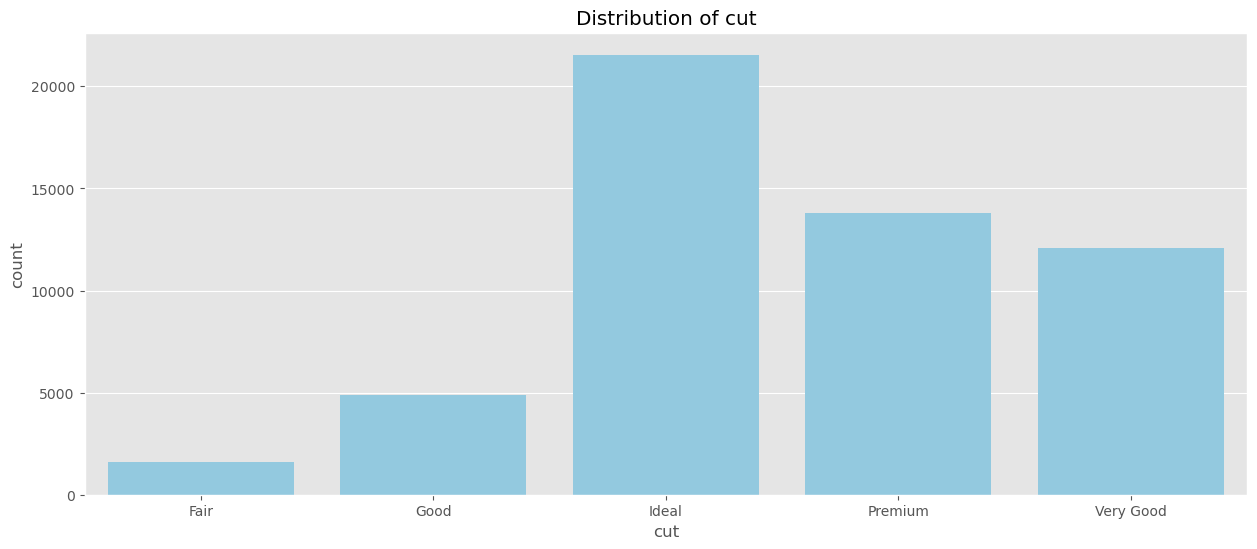

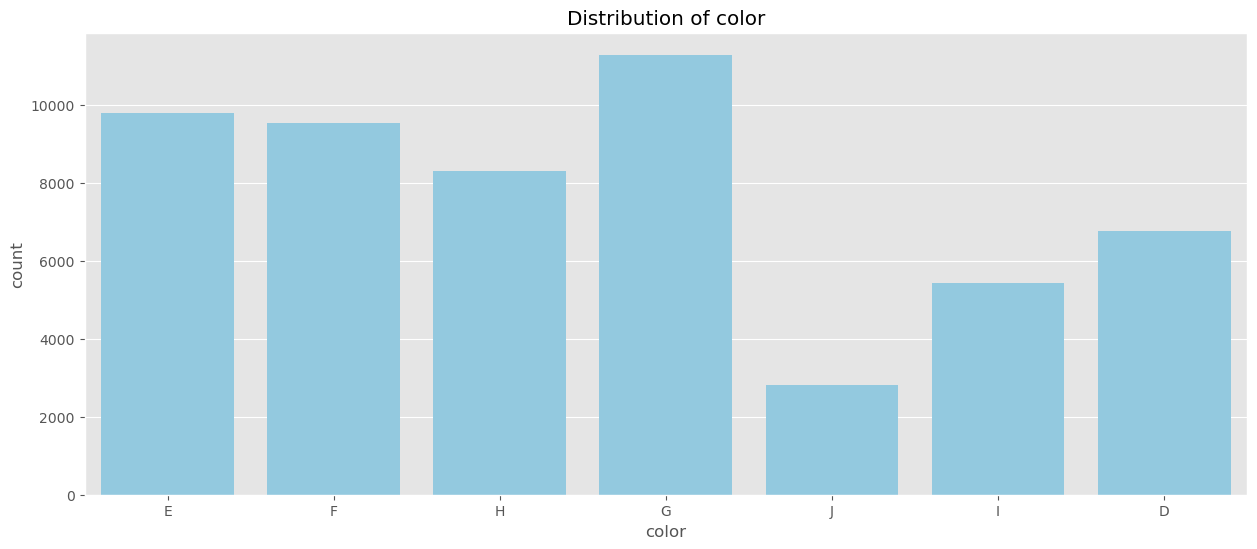

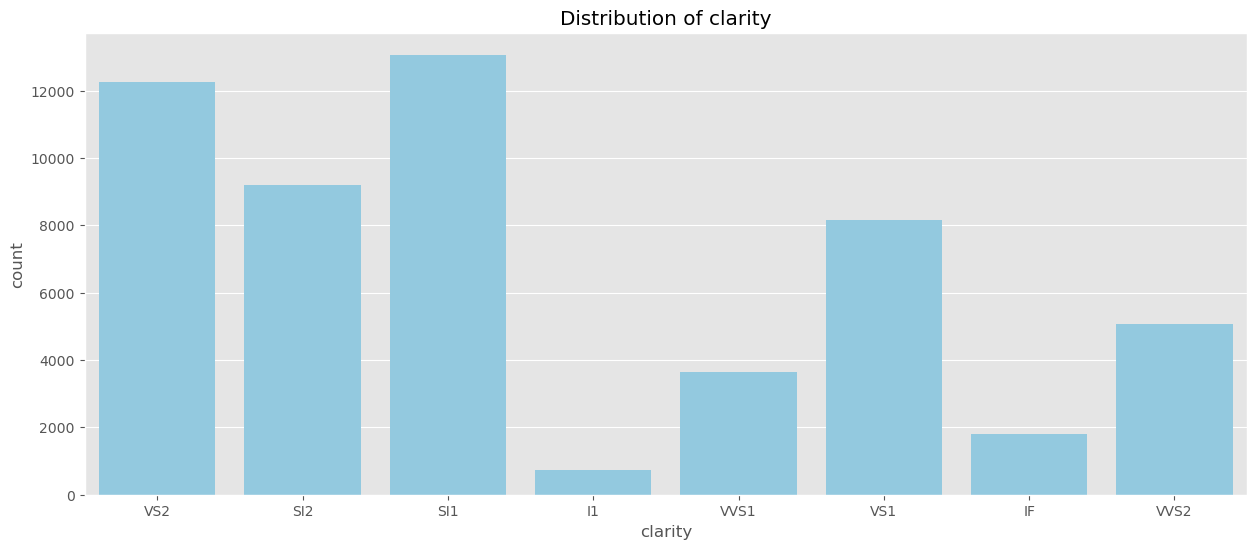

In [196]:
# visualize the distribution of the categorical columns
for col in categorical_columns:
    fig, ax = plt.subplots(figsize=(15, 6))
    sns.countplot(x=col, data=df, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.show()

<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">

🖐️ **Insight:**   
- The distribution of the categorical columns is not balanced. This may affect the performance of the model. Therefore, we may need to consider encoding these categorical columns appropriately before training the model.
</div>

____

## **Data Visualization**: Numerical Attributes

To have the insights of the numerical attributes, we will emplore the following numerical checks on the dataset:
- Summary statistics (mean, median, min, max, etc.)
- KDE plots for distribution
- Box plots for outliers
- Correlation matrix for relationships

This will help us to understand the distribution of numerical attributes and identify any outliers or correlations between them.

### <h3 id='daily-returns' style="font-family: 'Cambria', Georgia, serif; font-weight: bold; margin-bottom: 20px; text-align: left; letter-spacing: 1px;">1. Summary Statisitcs</h2>

In [197]:
# exploring the statistics of the numerical columns
df[numerical_columns].describe().round(2)

,carat,depth,table,price,x_factor,z_factor,y_factor
count,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00,53940.00
mean,0.80,61.75,57.46,3932.80,5.73,3.54,5.73
std,0.47,1.43,2.23,3989.44,1.12,0.71,1.14
min,0.20,43.00,43.00,326.00,0.00,0.00,0.00
25%,0.40,61.00,56.00,950.00,4.71,2.91,4.72
50%,0.70,61.80,57.00,2401.00,5.70,3.53,5.71
75%,1.04,62.50,59.00,5324.25,6.54,4.04,6.54
max,5.01,79.00,95.00,18823.00,10.74,31.80,58.90


<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">

🖐️ **Insight:**   
- The mean price of diamonds is around 3933, and while the mean carat weight is 0.8, the mean depth percentage is 61.7. 
- The standard deviation of price is quite high, indicating a wide range of prices in the dataset. 
- The carat weight also has a large standard deviation, suggesting a wide range of carat weights in the dataset. 
- The high standard deviation of price and carat weight indicates that the data is spread out over a wide range of values.The understanding of the summary statistics will help us to identify the range of values for each attribute and detect any potential outliers.

</div>

___

### <h3 id='daily-returns' style="font-family: 'Cambria', Georgia, serif; font-weight: bold; margin-bottom: 20px; text-align: left; letter-spacing: 1px;">2. KDE visualisation</h2>

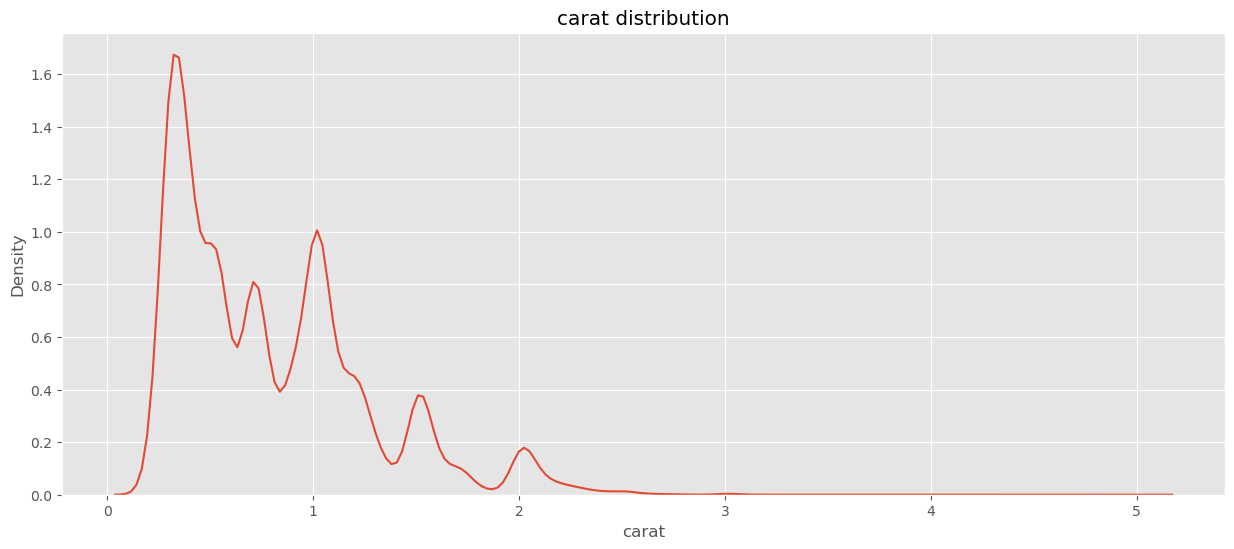

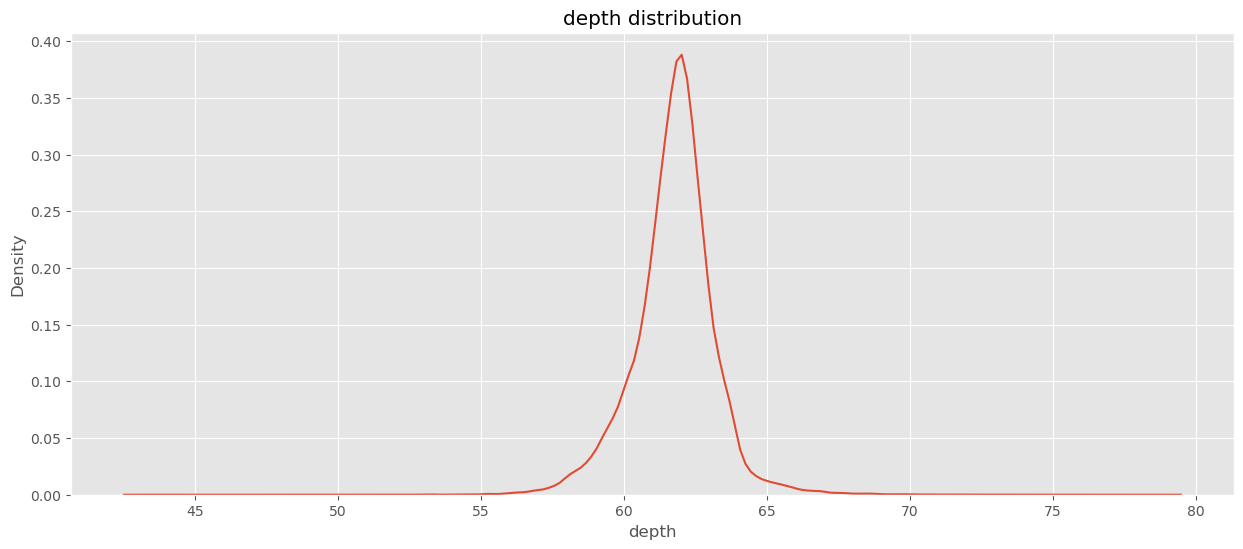

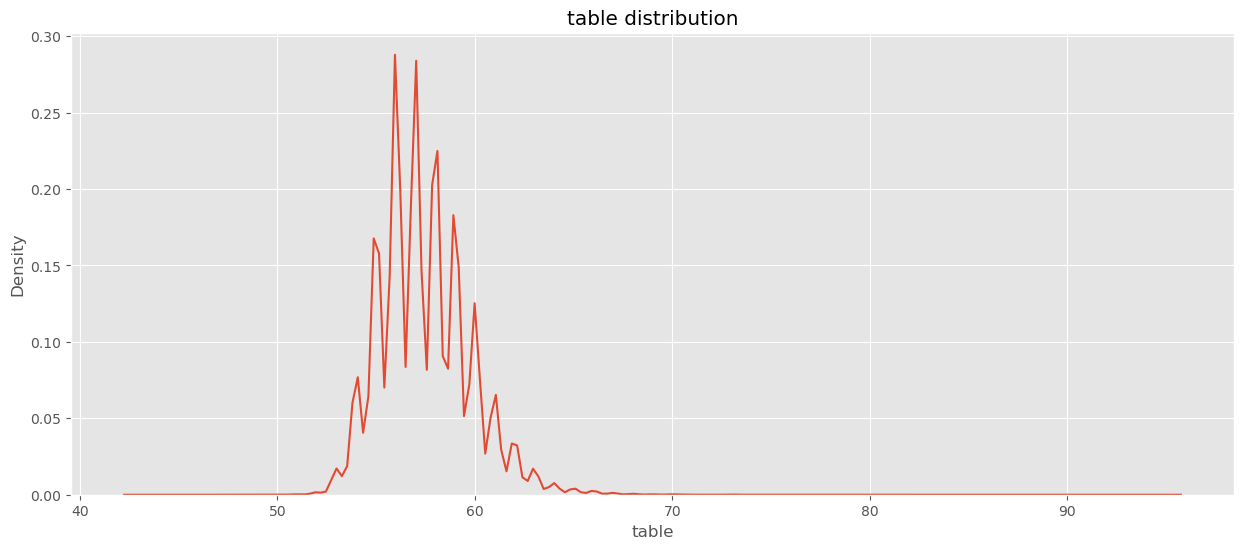

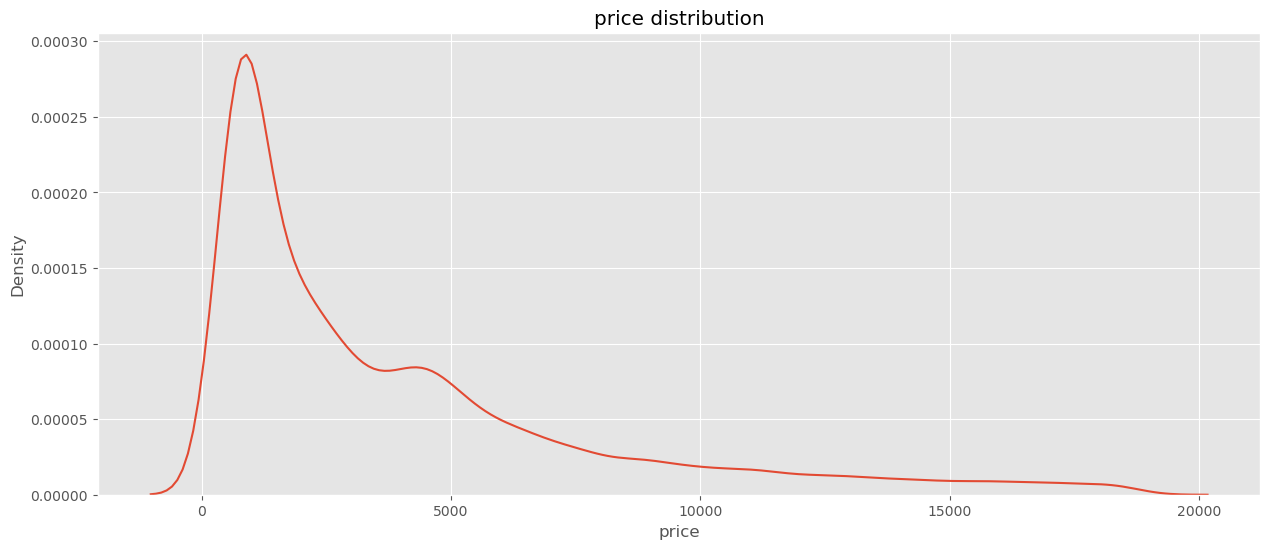

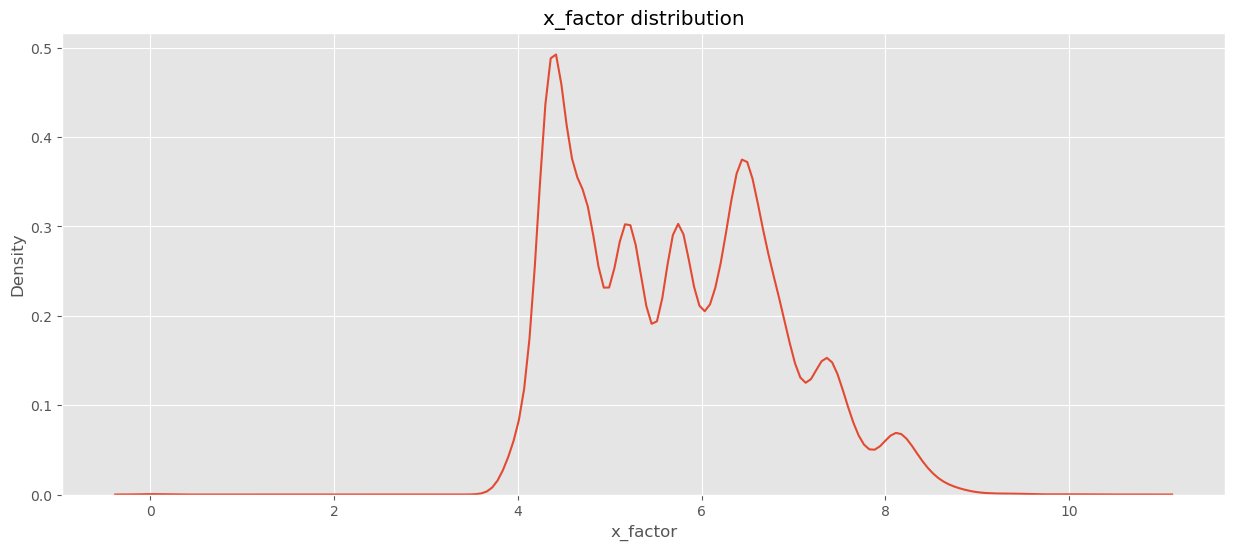

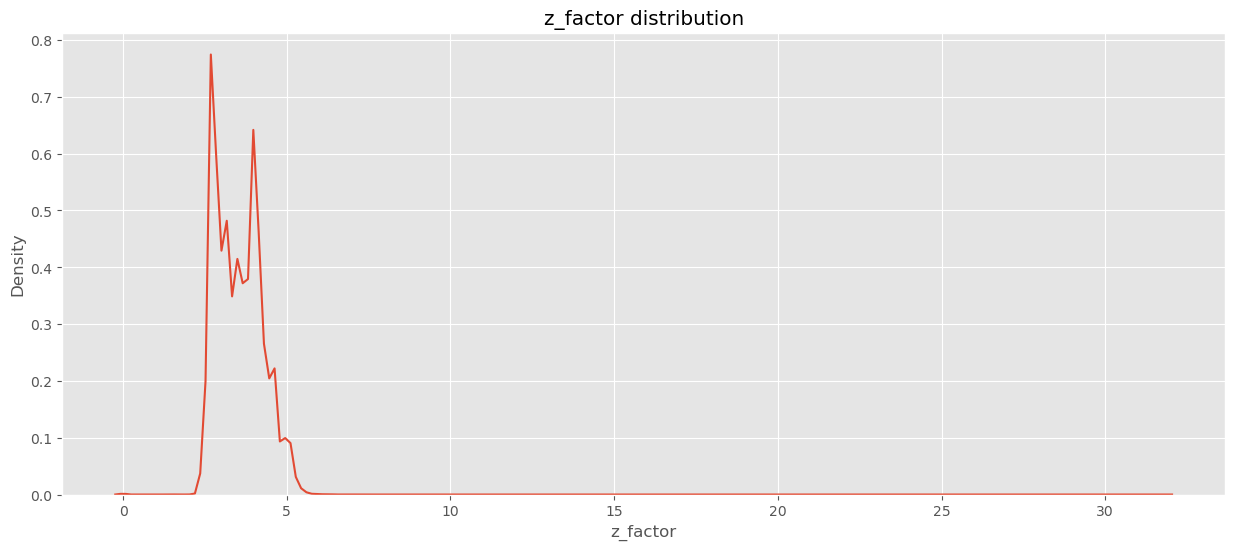

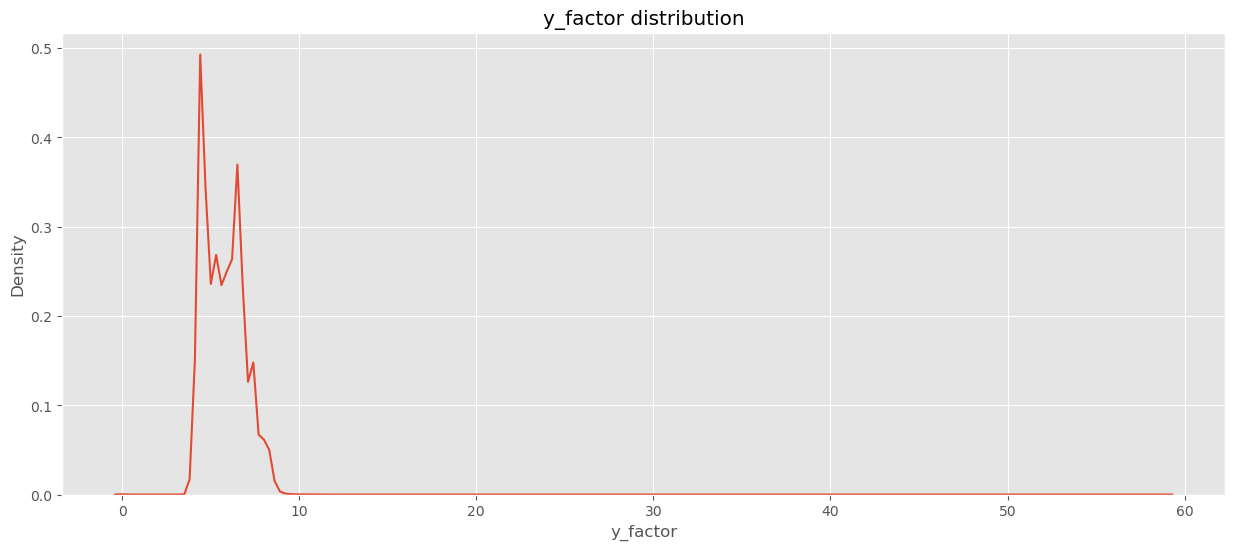

In [198]:
# plotting the  kde for the numerical columns
for col in numerical_columns:
    plt.figure(figsize=(15,6), dpi=100, facecolor='w', edgecolor='k')
    sns.kdeplot(df[col])
    plt.title(f'{col} distribution')
    plt.show()

<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">

🖐️ **Insight:**   

- From the diagram above, we can see that the carat attribute has a right-skewed distribution, with most diamonds having a carat weight of less than 1. 
- The price attribute also has a right-skewed distribution, with most diamonds priced below $5,000. 
- The depth and table attributes have relatively normal distributions, with depth ranging from 55 to 70 and table ranging from 50 to 70.
- Understanding the distribution of numerical attributes will help us to identify patterns and trends in the data and make informed decisions during model development.

</div>

___

### <h3 id='daily-returns' style="font-family: 'Cambria', Georgia, serif; font-weight: bold; margin-bottom: 20px; text-align: left; letter-spacing: 1px;">3. Outliers of attributes</h2>

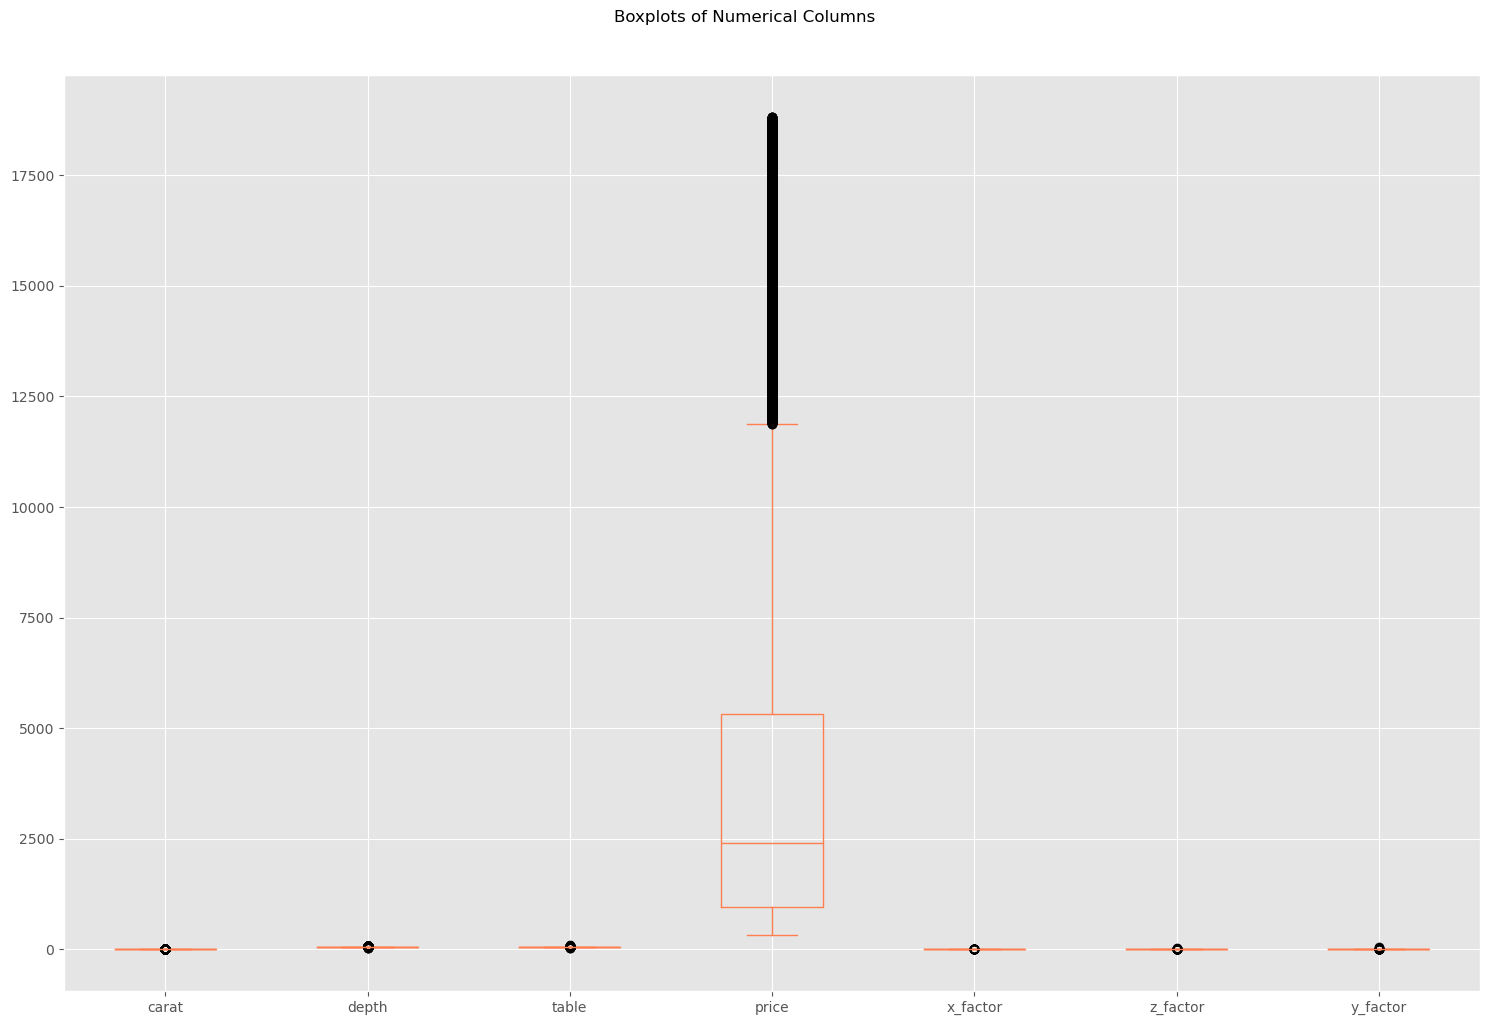

In [199]:
# plotting the boxplot for the numerical columns
df[numerical_columns].boxplot(figsize=(15,10), color='coral')
plt.suptitle('Boxplots of Numerical Columns', x=0.5, y=1.02, ha='center', fontsize='large')
plt.tight_layout()
plt.show()

From the box plots, it is obvious that the price have a lot of outliers. This is important to note because outliers can affect the performance of machine learning models. Therefore, we need to consider removing or transforming these outliers before training the model.

To help visualize the outliers comparatively, we will plot all the numerical attributes in the dataset within the same range

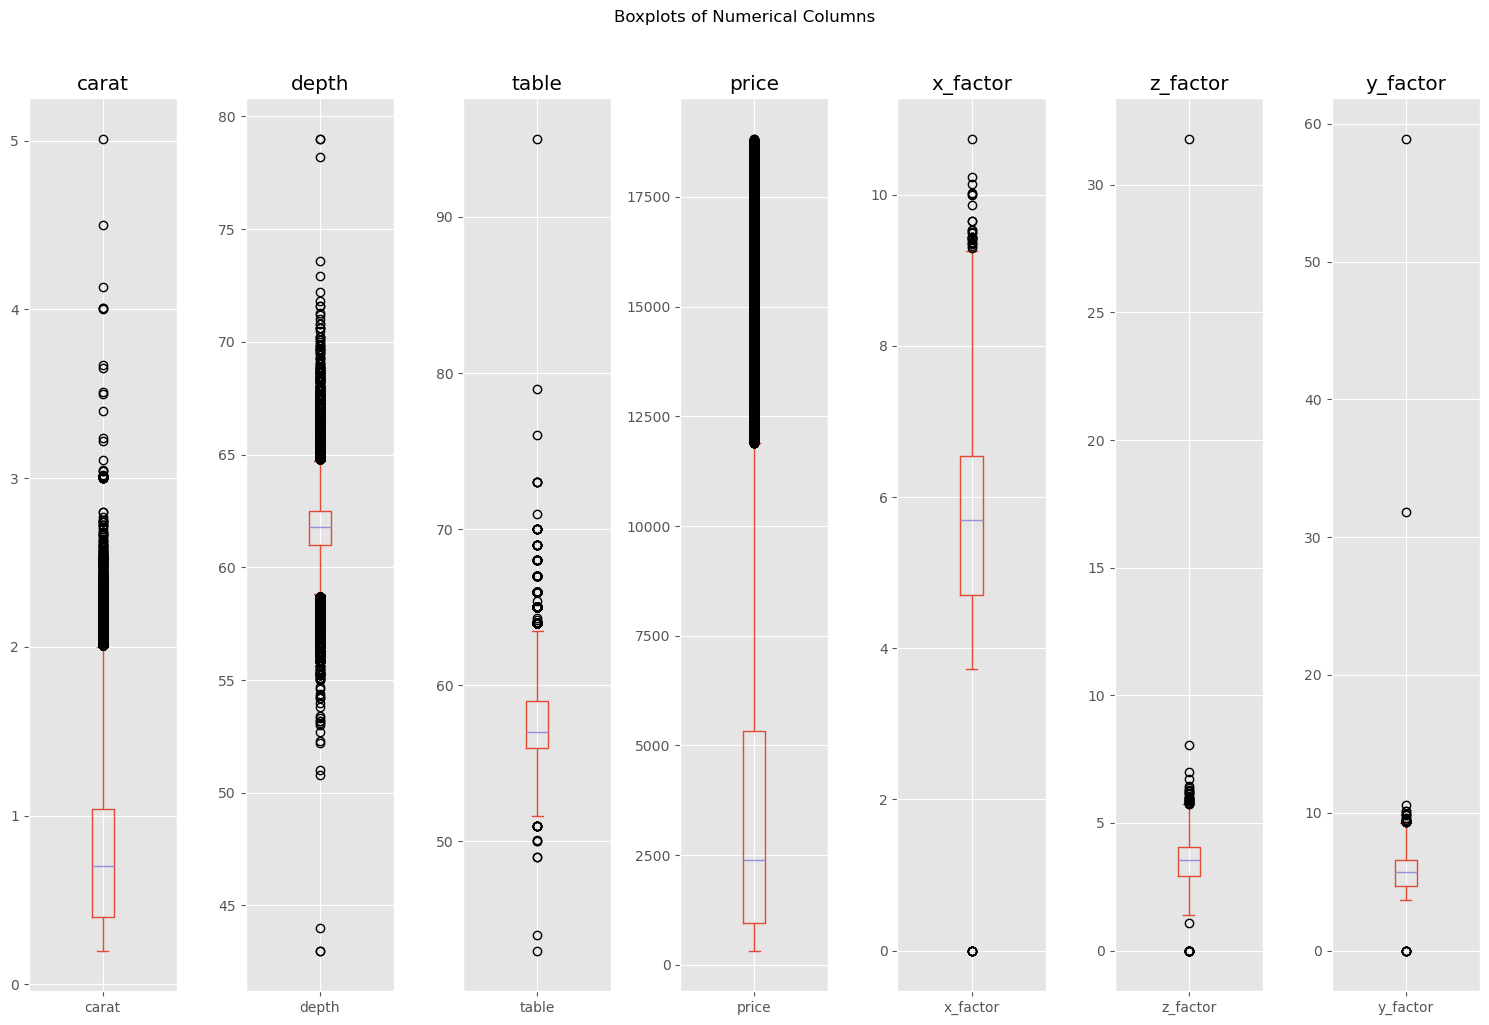

In [200]:
# plotting the boxplot for the numerical columns
fig, axes = plt.subplots(1, len(numerical_columns), figsize=(15, 10))
plt.suptitle('Boxplots of Numerical Columns', x=0.5, y=1.02, ha='center', fontsize='large')
for i, column in enumerate(numerical_columns):
    df[column].plot(kind='box', ax=axes[i])
    axes[i].set_title(column)
plt.tight_layout()
plt.show()

<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">

🖐️ **Insight:**   
- The price attribute has a significant number of outliers, with one diamond priced at $18,823. This outlier may need further investigation to determine if it is a valid data point or an error in the dataset.
- The carat attribute also has a few outliers, with one diamond weighing over 4 carats. These outliers may need to be addressed to prevent them from affecting the model's performance.
- The depth and table attributes do not have many outliers, indicating that most diamonds fall within a normal range of values for these attributes.

</div>

____

### <h3 id='daily-returns' style="font-family: 'Cambria', Georgia, serif; font-weight: bold; margin-bottom: 20px; text-align: left; letter-spacing: 1px;">4. Correlation of attributes</h2>

In [201]:
# plotting the correlation matrix
corr_matrix = df[numerical_columns].corr().round(2)
corr_matrix

,carat,depth,table,price,x_factor,z_factor,y_factor
carat,1.00,0.03,0.18,0.92,0.98,0.95,0.95
depth,0.03,1.00,-0.30,-0.01,-0.03,0.09,-0.03
table,0.18,-0.30,1.00,0.13,0.20,0.15,0.18
price,0.92,-0.01,0.13,1.00,0.88,0.86,0.87
x_factor,0.98,-0.03,0.20,0.88,1.00,0.97,0.97
z_factor,0.95,0.09,0.15,0.86,0.97,1.00,0.95
y_factor,0.95,-0.03,0.18,0.87,0.97,0.95,1.00


To understand the relationships between numerical attributes, We will extract the correlation matrix of the dataset and visualize it using a heatmap.

In [202]:
corr_matrix['price'].sort_values(ascending=False)

price       1.00
carat       0.92
x_factor    0.88
y_factor    0.87
z_factor    0.86
table       0.13
depth      -0.01
Name: price, dtype: float64

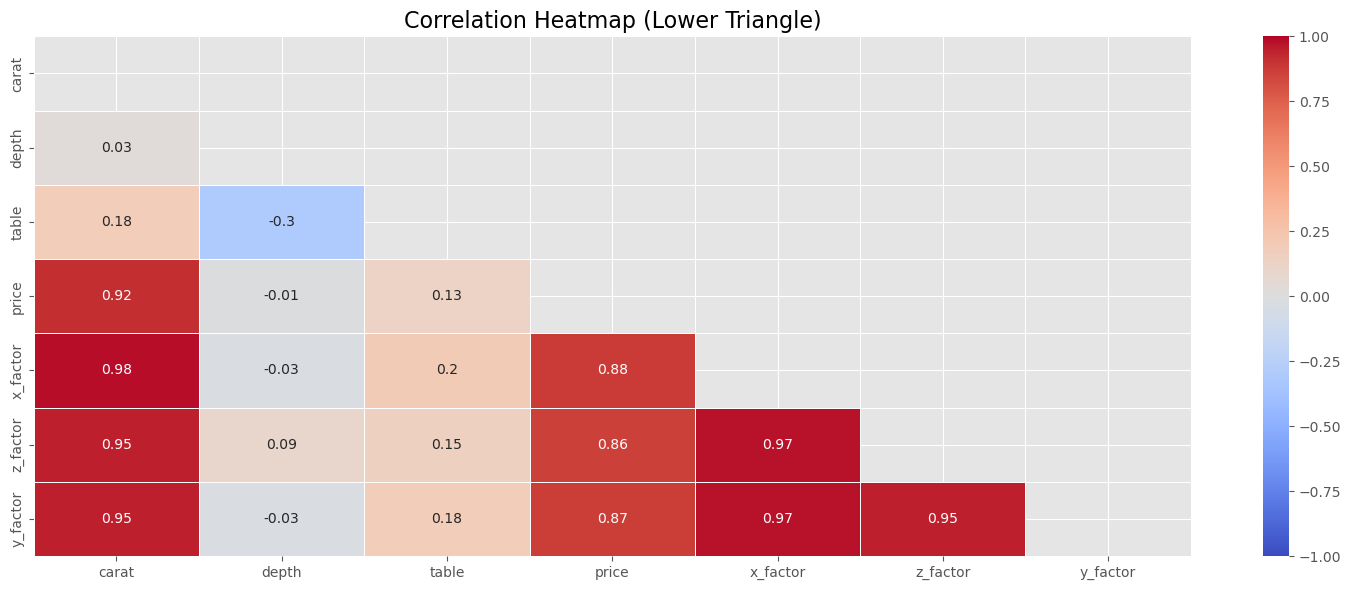

In [203]:
# Create a mask for the upper triangle
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# Plot the heatmap with the mask
plt.figure(figsize=(15, 6))
sns.heatmap(
    corr_matrix, 
    mask=mask,               # Apply the mask to hide the upper triangle
    annot=True,              # Show correlation values
    cmap='coolwarm',         # Color map
    linewidths=0.5,          # Grid line width
    vmin=-1, vmax=1          # Fix color scale from -1 to 1
)
plt.title('Correlation Heatmap (Lower Triangle)', fontsize=16)
plt.tight_layout()
plt.show()

<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">

🖐️ **Insight:**   
- The carat attribute has a strong positive correlation with the price attribute <font color = red> (0.92) </font>, indicating that larger diamonds tend to be more expensive.
- The depth<font color = red> (-0.01) </font>, and table <font color = red> (0.13) </font> attributes have weak correlations with the price attribute, suggesting that they may not be significant predictors of diamond price.
- The x_factor, z_factor, and y_factor attributes  of <font color = red> 0.88 , 0.86, 0.87 </font> respectively have positive correlations with the price attribute, indicating that larger dimensions tend to be associated with higher prices.

</div>

From the above, it is instructive to note that the `carat` attribute has the highest correlation with the price <font color = red> (0.92) </font>, attribute, followed `x_factor`, `z_factor`, and `y_factor` attributes  of <font color = red> 0.88 , 0.86, 0.87 </font> respectively

This suggests that carat weight and dimensions are important predictors of diamond price. The other attributes (depth, and table) have weaker correlations with the price attribute, indicating that they may not be as significant in predicting diamond prices.     

This relationship will be further explored in the feature engineering section, and it is best explained with the help of a scatter plot using the scatter plot to visualize the relationship between the carat attribute and the price attribute.

<Figure size 1500x600 with 0 Axes>

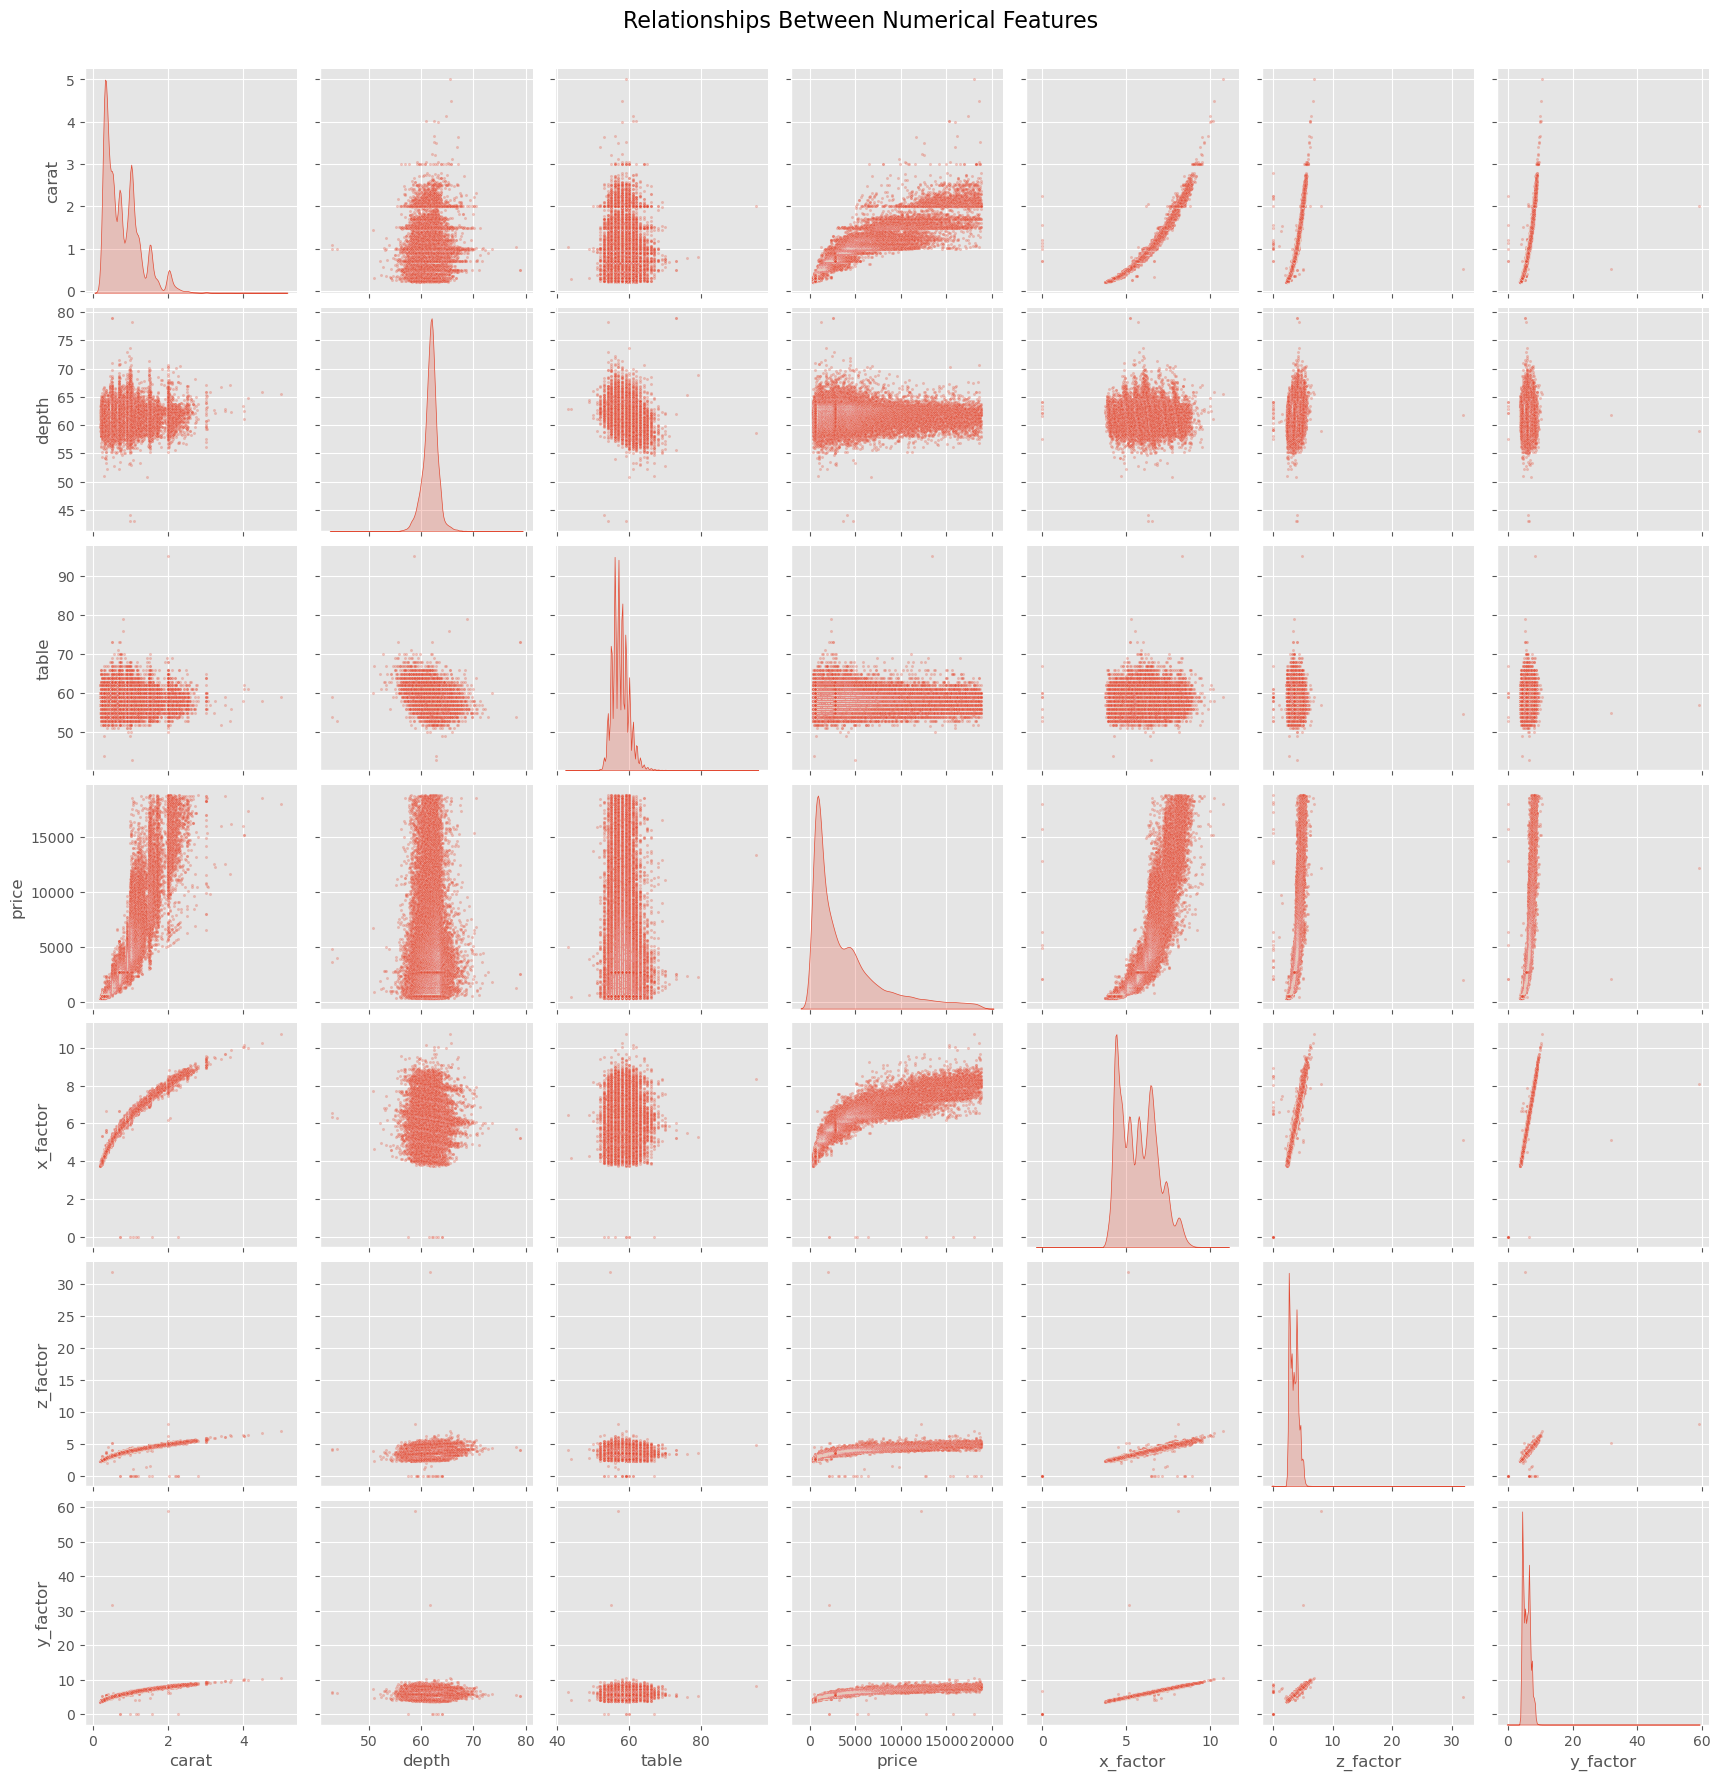

In [204]:
# Plotting the pairplot
plt.figure(figsize=(15, 6))
sns.pairplot(
    df[numerical_columns],
    diag_kind='kde',     # KDE on diagonal
    plot_kws={'alpha': 0.3, 's': 5},
    height=2.5           # Size of each subplot
)
plt.suptitle('Relationships Between Numerical Features', y=1.02, fontsize=16)
plt.show()

<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">

🖐️ **Insight:**   
- From the pairplot above, it is obvious that carat and price have a strong positive correlation with the scatter plot showing a linear relationship between the two attributes.
- The scatter plot also shows price have linear relationship with the x_factor, z_factor, and y_factor attributes, indicating that larger dimensions tend to be associated with higher prices.
- The depth and table attributes do not show a clear relationship with the price attribute, suggesting that they may not be significant predictors of diamond price.

### <h3 id='daily-returns' style="font-family: 'Cambria', Georgia, serif; font-weight: bold; margin-bottom: 20px; text-align: left; letter-spacing: 1px;">5. Scatter plot of Key attributes</h2>

To better understand the relationship between the carat attribute and the price attribute, we will zoom in on the scatter plot to examine the data points more closely.

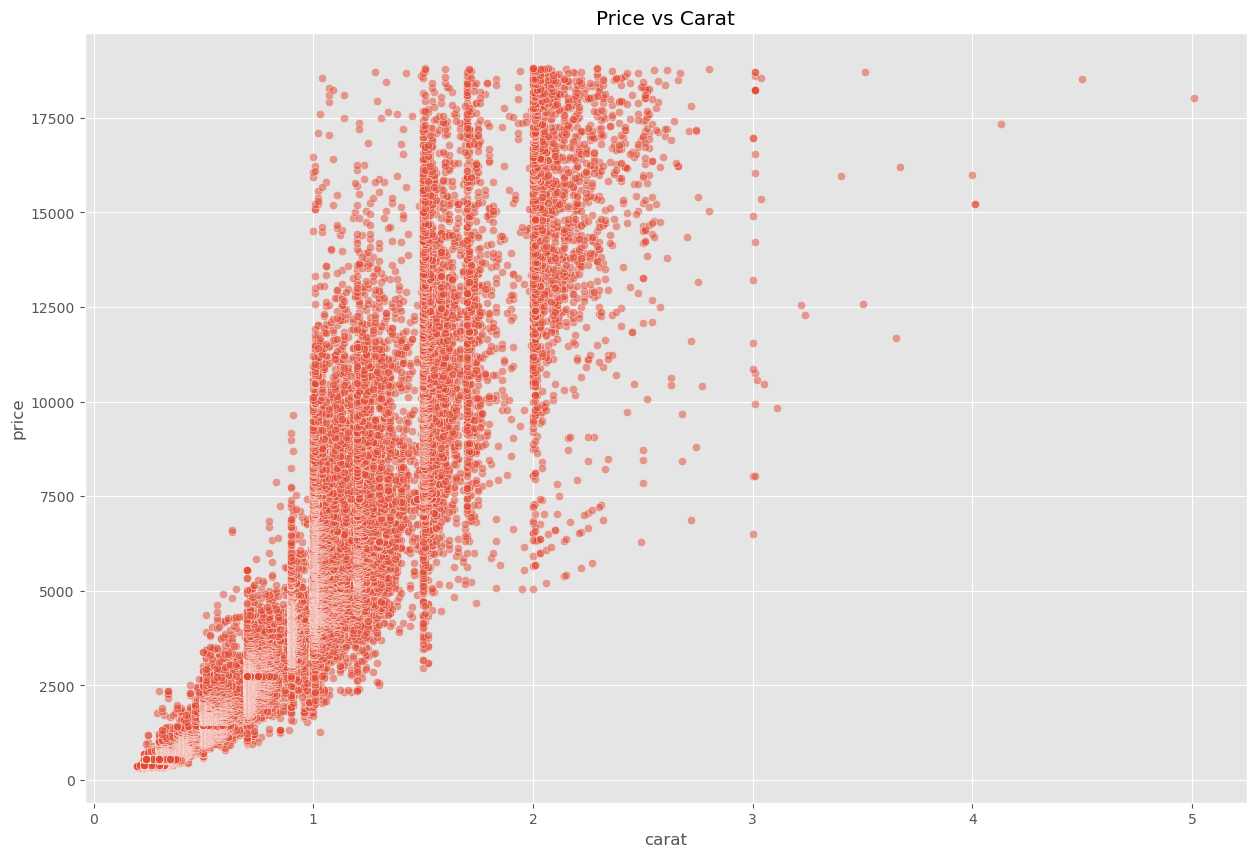

In [205]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
sns.scatterplot(data=df, x='carat', y='price', alpha=0.5, ax=ax )
plt.title('Price vs Carat')
plt.show()

It will be interesting to see how the cut, color, and clarity of diamonds affect their prices.

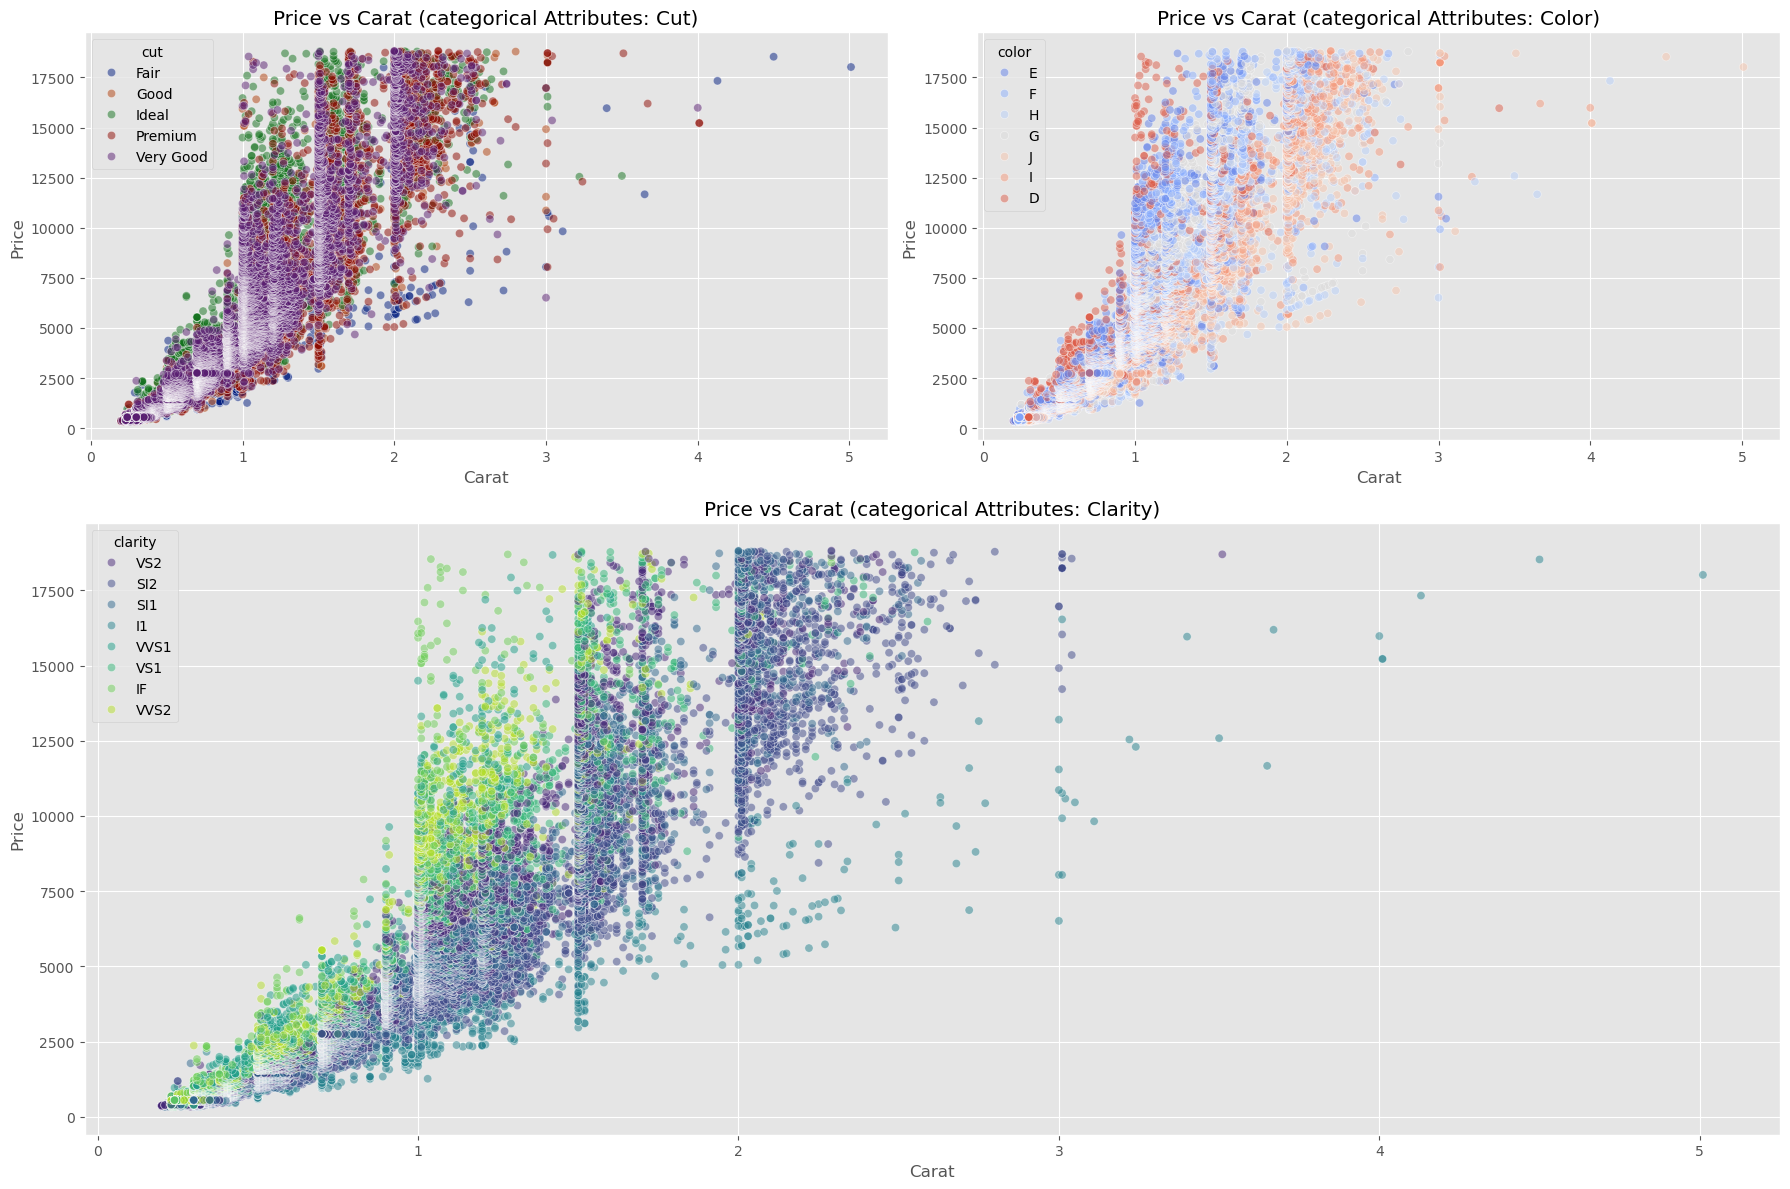

In [206]:

# Create figure and GridSpec layout
fig = plt.figure(figsize=(18, 12))
grid = GridSpec(2, 2, figure=fig, height_ratios=[1, 1.5])  # Make bottom row bigger

# Scatter plot for 'cut'
ax1 = fig.add_subplot(grid[0, 0])
sns.scatterplot(data=df, x='carat', y='price', hue='cut', alpha=0.5, palette='dark', ax=ax1)
ax1.set_title('Price vs Carat (categorical Attributes: Cut)')
ax1.set_xlabel('Carat')
ax1.set_ylabel('Price')

# Scatter plot for 'color'
ax2 = fig.add_subplot(grid[0, 1])
sns.scatterplot(data=df, x='carat', y='price', hue='color', alpha=0.5, palette='coolwarm', ax=ax2)
ax2.set_title('Price vs Carat (categorical Attributes: Color)')
ax2.set_xlabel('Carat')
ax2.set_ylabel('Price')

# Large Scatter plot for 'clarity' spanning entire second row
ax3 = fig.add_subplot(grid[1, :])
sns.scatterplot(data=df, x='carat', y='price', hue='clarity', alpha=0.5, palette='viridis', ax=ax3)
ax3.set_title('Price vs Carat (categorical Attributes: Clarity)')
ax3.set_xlabel('Carat')
ax3.set_ylabel('Price')

plt.tight_layout()
plt.show()


<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">

🖐️ **Insight:**   
- From the scatter plot above, we can see that the carat attribute has a linear relationship with the price attribute, with larger diamonds tending to be more expensive. 
- The scatter plot also shows that the cut attribute has a significant impact on the price of diamonds, with higher color grades corresponding to higher prices. 
- The cut and clarity attributes also have an impact on diamond prices, with higher cut and clarity grades corresponding to higher prices.

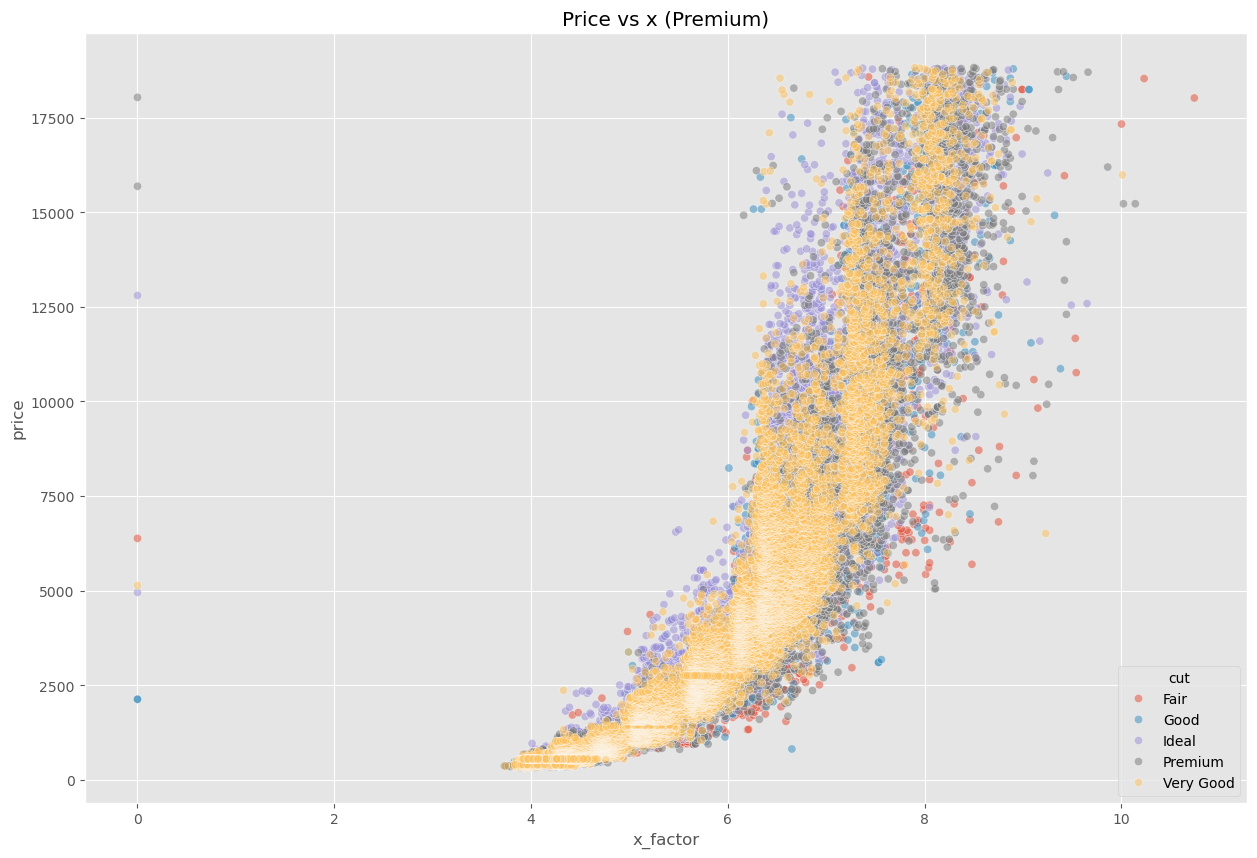

In [207]:
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
sns.scatterplot(data=df, x='x_factor', y='price', hue='cut', alpha=0.5, ax=ax)
plt.title('Price vs x (Premium)')
plt.show()

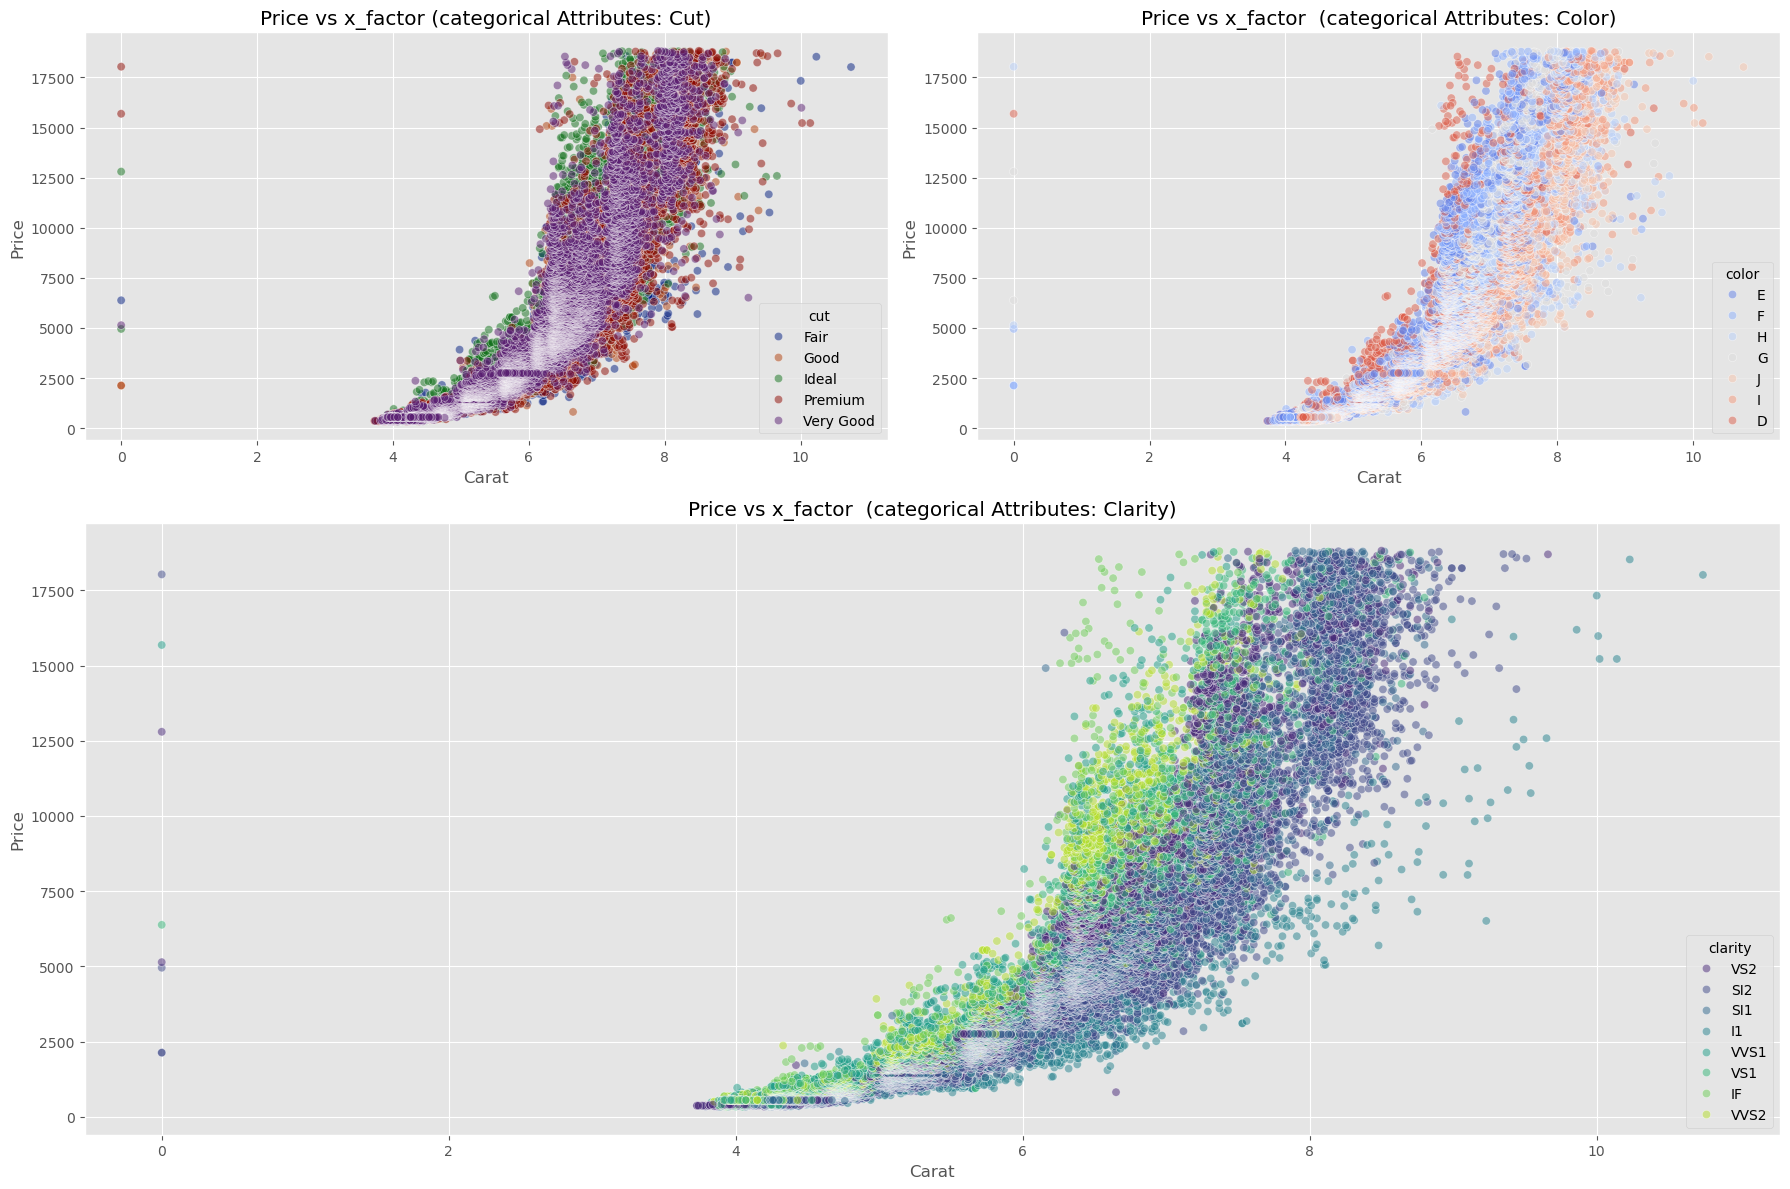

In [208]:

# Create figure and GridSpec layout
fig = plt.figure(figsize=(18, 12))
grid = GridSpec(2, 2, figure=fig, height_ratios=[1, 1.5])  # Make bottom row bigger

# Scatter plot for 'cut'
ax1 = fig.add_subplot(grid[0, 0])
sns.scatterplot(data=df, x='x_factor', y='price', hue='cut', alpha=0.5, palette='dark', ax=ax1)
ax1.set_title('Price vs x_factor (categorical Attributes: Cut)')
ax1.set_xlabel('Carat')
ax1.set_ylabel('Price')

# Scatter plot for 'color'
ax2 = fig.add_subplot(grid[0, 1])
sns.scatterplot(data=df, x='x_factor', y='price', hue='color', alpha=0.5, palette='coolwarm', ax=ax2)
ax2.set_title('Price vs x_factor  (categorical Attributes: Color)')
ax2.set_xlabel('Carat')
ax2.set_ylabel('Price')

# Large Scatter plot for 'clarity' spanning entire second row
ax3 = fig.add_subplot(grid[1, :])
sns.scatterplot(data=df, x='x_factor', y='price', hue='clarity', alpha=0.5, palette='viridis', ax=ax3)
ax3.set_title('Price vs x_factor  (categorical Attributes: Clarity)')
ax3.set_xlabel('Carat')
ax3.set_ylabel('Price')

plt.tight_layout()
plt.show()

<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">

🖐️ **Insight:**   
- There is a clear positive correlation between the X_factor attribute and the price attribute, with larger diamonds tending to be more expensive.
- The cut, color, and clarity attributes also have a significant impact on diamond prices, with higher grades corresponding to higher prices.

___

## **Data Visualization:** Target Variable (Price)

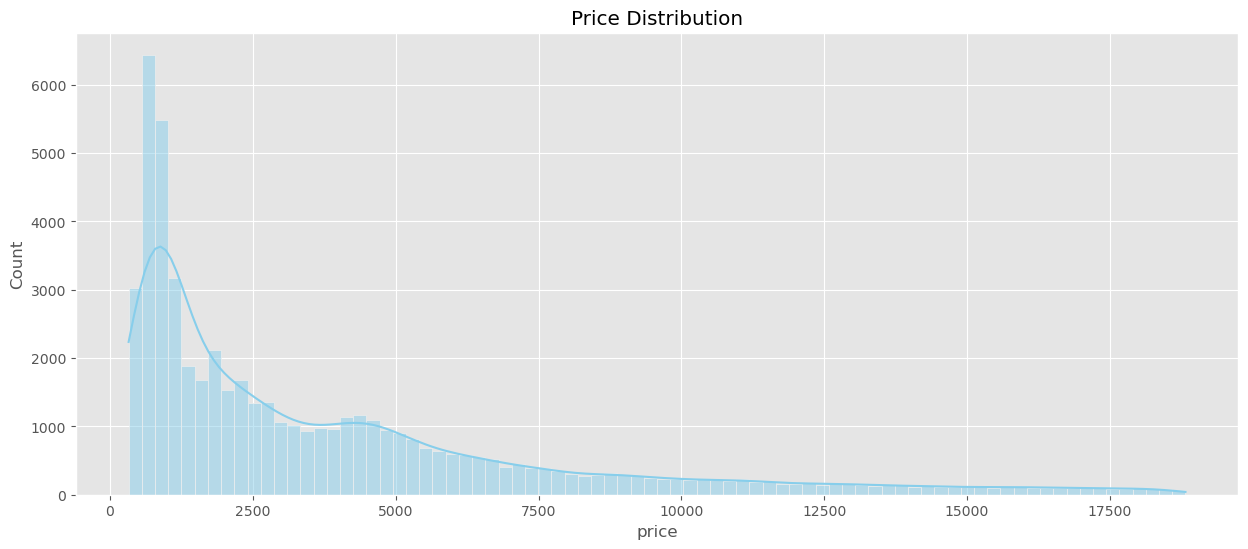

In [209]:
fig, ax = plt.subplots(figsize=(15, 6))
sns.histplot(df['price'], kde=True, color='skyblue')
plt.title('Price Distribution')
plt.show()


<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">

🖐️ **Insight:**   
- The price attribute has a right-skewed distribution, with most diamonds priced below $5,000.
- The distribution of prices is not balanced, with a few diamonds priced above $10,000. 
- This may affect the performance of the model, as it may be biased towards predicting lower prices.
- We need to consider transforming the price attribute to achieve a more normal distribution and improve model performance.

# 📚 4. SETTING UP THE VALIDATION FRAMEWORK
___

<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">
This section will focus on setting up the validation framework for training and evaluating machine learning models. We will split the data into training and testing sets, define evaluation metrics, and implement cross-validation to assess model performance.

</div>

In [210]:
# import the model from the sklearn library
from sklearn.model_selection import train_test_split

# split the dataset into train and test dataset
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=11)

# split the train dataset into train and validation dataset
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=11)

In [211]:
# check the shape of the datasets§
len(df_train), len(df_val), len(df_test)

(32364, 10788, 10788)

In [212]:
# reset the index of the dataset
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [213]:
# assigning the target variables to the y_train from the df_train
y_train = df_train['price'].values

# assigning the target variables to the y_test from the df_test
y_test = df_test['price'].values

# assigning the target variables to the y_val from the df_val
y_val = df_val['price'].values

In [214]:
# drop the target variable from the dataset
del df_train['price']
del df_test['price']
del df_val['price']

it is important to check the data frame after the data processing. This is important to know the number of rows and columns in the dataset.

In [226]:
# check the head of the train dataset
df_train.head()

,cut,color,clarity,carat,depth,table,x_factor,z_factor,y_factor
0,Very Good,I,VS1,1.20,62.8,54.5,6.75,4.25,6.79
1,Ideal,F,VVS2,1.15,62.1,55.0,6.69,4.17,6.74
2,Premium,G,VS1,1.08,62.0,60.0,6.55,4.05,6.51
3,Ideal,F,VS2,0.32,62.2,55.0,4.35,2.71,4.37
4,Very Good,H,SI1,1.10,62.9,57.0,6.54,4.13,6.59


In [227]:
# shape of the train dataset
df_train.shape

(32364, 9)

In [216]:
# check the head of the test dataset
df_test.head()

,cut,color,clarity,carat,depth,table,x_factor,z_factor,y_factor
0,Ideal,H,VS2,1.62,62.4,57.0,7.48,4.68,7.53
1,Premium,F,SI2,1.01,61.7,58.0,6.46,3.97,6.41
2,Ideal,F,VVS2,0.54,61.0,54.0,5.28,3.23,5.30
3,Ideal,E,VS1,0.40,60.1,57.0,4.77,2.88,4.82
4,Premium,H,VS1,1.00,60.7,59.0,6.44,3.90,6.40


In [228]:
# shape of the test dataset
df_test.shape

(10788, 9)

In [217]:
# check the head of the validation dataset
df_val.head()

,cut,color,clarity,carat,depth,table,x_factor,z_factor,y_factor
0,Premium,D,VS2,0.46,60.9,58.0,4.97,3.02,4.94
1,Ideal,E,VS2,0.36,62.6,56.0,4.52,2.84,4.56
2,Premium,E,VS1,0.39,58.8,59.0,4.76,2.79,4.73
3,Fair,J,VS1,0.90,64.6,58.0,6.12,3.93,6.06
4,Ideal,E,VS1,0.31,61.3,54.0,4.37,2.69,4.40


In [229]:
# shape of the validation dataset
df_val.shape

(10788, 9)

# 📚 5. FEATURES ENGINEERING
___

<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">
This section will focus on feature engineering, including creating new features, transforming existing features, and selecting relevant features for model training. We will also handle categorical encoding and feature scaling to prepare the data for machine learning.

</div>

From the data exploration, there are few  data transformation and feature engineering that can be done to improve the model performance. These include:
- Remove outliers from numerical columns
- Encode categorical variable
- Transform the target variable (price)
- Ensure the same transformation logic is applied across val/test sets

The focus on this transformation is on train data set, and the same transformation will be applied to the test data set.

## **Remove Outliers**: (Based on df_train only):

The outliers in the price attribute will be removed from the `training set` (df_training) to prevent them from affecting the model's performance. This will help to improve the accuracy of the model by removing data points that may skew the predictions.

There are 4 steps of removing outliers:
- identify the numericals for the outliers
- Calculate the 25th and 75th percentiles of the numeric attribute, and the interquartile range (IQR).
- Apply the IQR bounds across the training, validation, and test dataset
- Align and updte the target variable (price) in the training, validation, and test dataset

#### 📌 Step 1: Identify the numerical columns for the outliers

First step is to identify the numerical columns in the dataset that contain outliers. This will help us to focus on the relevant attributes when removing outliers from the training set.

In [256]:
# Get numerical columns (excluding 'price')
numerical_columns_without_price = ['carat', 'depth', 'table', 'x_factor', 'z_factor', 'y_factor']

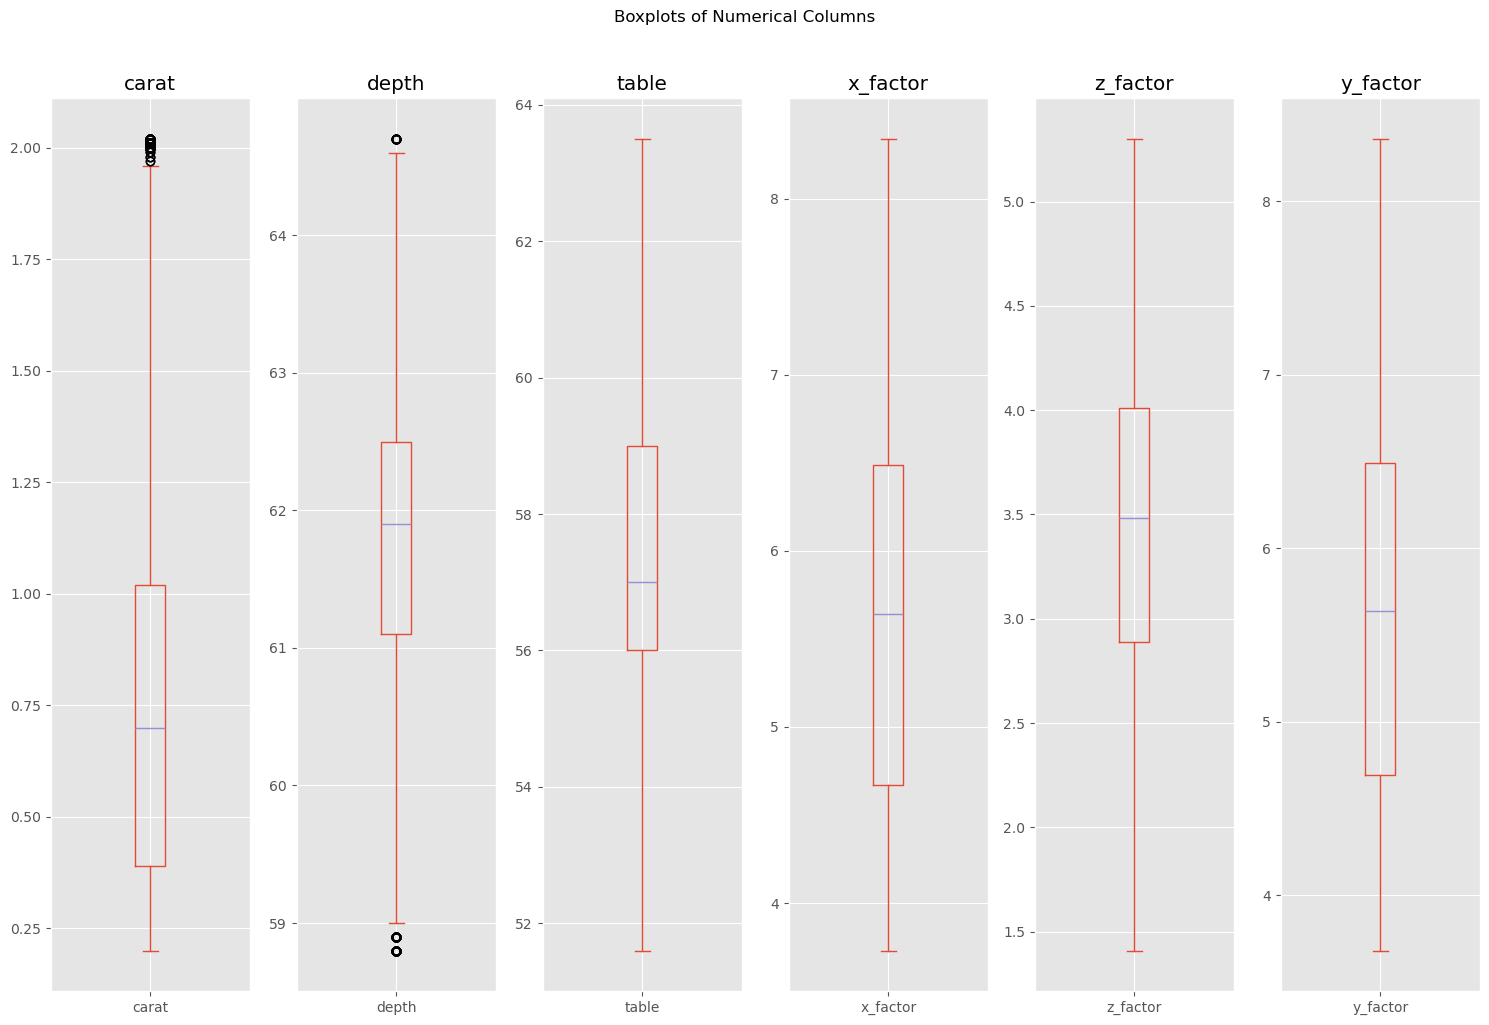

In [257]:
# plotting the boxplot for the numerical columns without price
fig, axes = plt.subplots(1, len(numerical_columns_without_price), figsize=(15, 10))
plt.suptitle('Boxplots of Numerical Columns', x=0.5, y=1.02, ha='center', fontsize='large')

for i, column in enumerate(numerical_columns_without_price):
    df_train[column].plot(kind='box', ax=axes[i])
    axes[i].set_title(column)
plt.tight_layout()
plt.show()

Always best practice to check the shape of the data frame both for the test, val, and train before applying the IQR

In [258]:
print('The dataframe shape before applying the IQR:')
print('df_train:', df_train.shape)
print('df_val:', df_val.shape)
print('df_test:', df_test.shape)

The dataframe shape before applying the IQR:
df_train: (29902, 9)
df_val: (9961, 9)
df_test: (9980, 9)


In [259]:
print( 'The target variable shape before applying the IQR:')
print('y_train:', y_train.shape)
print('y_val:', y_val.shape)
print('y_test:', y_test.shape)

The target variable shape before applying the IQR:
y_train: (29902,)
y_val: (9961,)
y_test: (9980,)


____

#### 📌 Step 2: Calculate the lower bound (0.25) and upper bound (0.75) of the data.




Secondly, we will calculate the lower and upper bounds for the outliers using the Interquartile Range (IQR) method. This will help us to identify data points that fall outside the normal range of values for each attribute. The formula for calculating the lower and upper bounds is as follows:

$$
\text{Lower Bound} = Q_1 - 1.5 \times \text{IQR}
$$

$$
\text{Upper Bound} = Q_3 + 1.5 \times \text{IQR}

§
$$


$$
\text{IQR} = Q_3 - Q_1

$$
Where:  
- $Q_1$ is the 25th percentile
- $Q_3$ is the 75th percentile
- $\text{IQR}$ is the Interquartile Range

The IQR method is a robust way to identify outliers in the data by considering the spread of values around the median. Data points that fall outside the lower and upper bounds are considered outliers and will be removed from the dataset. The IQR is best apply using a function to ensure the same logic is applied across the training, validation, and test datasets.


In [261]:
# function to get the IQR bounds
def get_iqr_bounds(df, columns):
    bounds = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        bounds[col] = (lower, upper)
    return bounds

# calling the function to get the IQR bounds
iqr_bounds = get_iqr_bounds(df_train, numerical_columns_without_price)

In [264]:
# Display the IQR bounds
for col, (lower, upper) in iqr_bounds.items():
    print(f"{col}: Lower Bound = {lower:.2f}, Upper Bound = {upper:.2f}")

carat: Lower Bound = -0.56, Upper Bound = 1.97
depth: Lower Bound = 59.00, Upper Bound = 64.60
table: Lower Bound = 51.50, Upper Bound = 63.50
x_factor: Lower Bound = 1.94, Upper Bound = 9.22
z_factor: Lower Bound = 1.21, Upper Bound = 5.69
y_factor: Lower Bound = 1.99, Upper Bound = 9.19


____

#### 📌 Step 3: Applied the IQR bounds across the training, validation, and test datasets:


Following the calculation of the lower and upper bounds for the outliers, we will apply these bounds to the training, validation, and test datasets to remove the outliers from the price attribute. This will help to ensure that the model is trained on clean data without any outliers that may affect its performance.

In [265]:
def apply_iqr_bounds(df, bounds):
    for col, (low, high) in bounds.items():
        df = df[(df[col] >= low) & (df[col] <= high)]
    return df.reset_index(drop=True)

# Apply IQR bounds to the train, validation, and test datasets
df_train = apply_iqr_bounds(df_train, iqr_bounds)
df_val = apply_iqr_bounds(df_val, iqr_bounds)
df_test = apply_iqr_bounds(df_test, iqr_bounds)

Again, it is best practice to check the shape of the data frame both for the test, val, and train after applying the IQR

In [267]:
print('The dataframe shape after applying the IQR:')
print('df_train:', df_train.shape)
print('df_val:', df_val.shape)
print('df_test:', df_test.shape)

The dataframe shape after applying the IQR:
df_train: (29214, 9)
df_val: (9722, 9)
df_test: (9747, 9)


#### 📌 Step 4: Align and filter the target varibales for outlier

It is important to ensure that the target variable (price) is aligned and filtered across the training, validation, and test datasets. This will help to maintain consistency in the data and prevent any discrepancies during model training and evaluation. The function below will help to align and filter the target variable for outliers in the datasets.

In [236]:
y_train = y_train[df_train.index]
y_val = y_val[df_val.index]
y_test = y_test[df_test.index]

Again, it is best practice to check the shape of the data frame both for the test, val, and train after applying the IQR

In [268]:
print( 'The target variable shape after applying the IQR:')
print('Training data: y_train:', y_train.shape)
print('Validation data: y_val:', y_val.shape)
print('Testing data: y_test:', y_test.shape)

The target variable shape after applying the IQR:
Training data: y_train: (29902,)
Validation data: y_val: (9961,)
Testing data: y_test: (9980,)


Following the removal of outliers data, we will visualise the distribution again to see the impact of the removal of the outliers on the attribute.

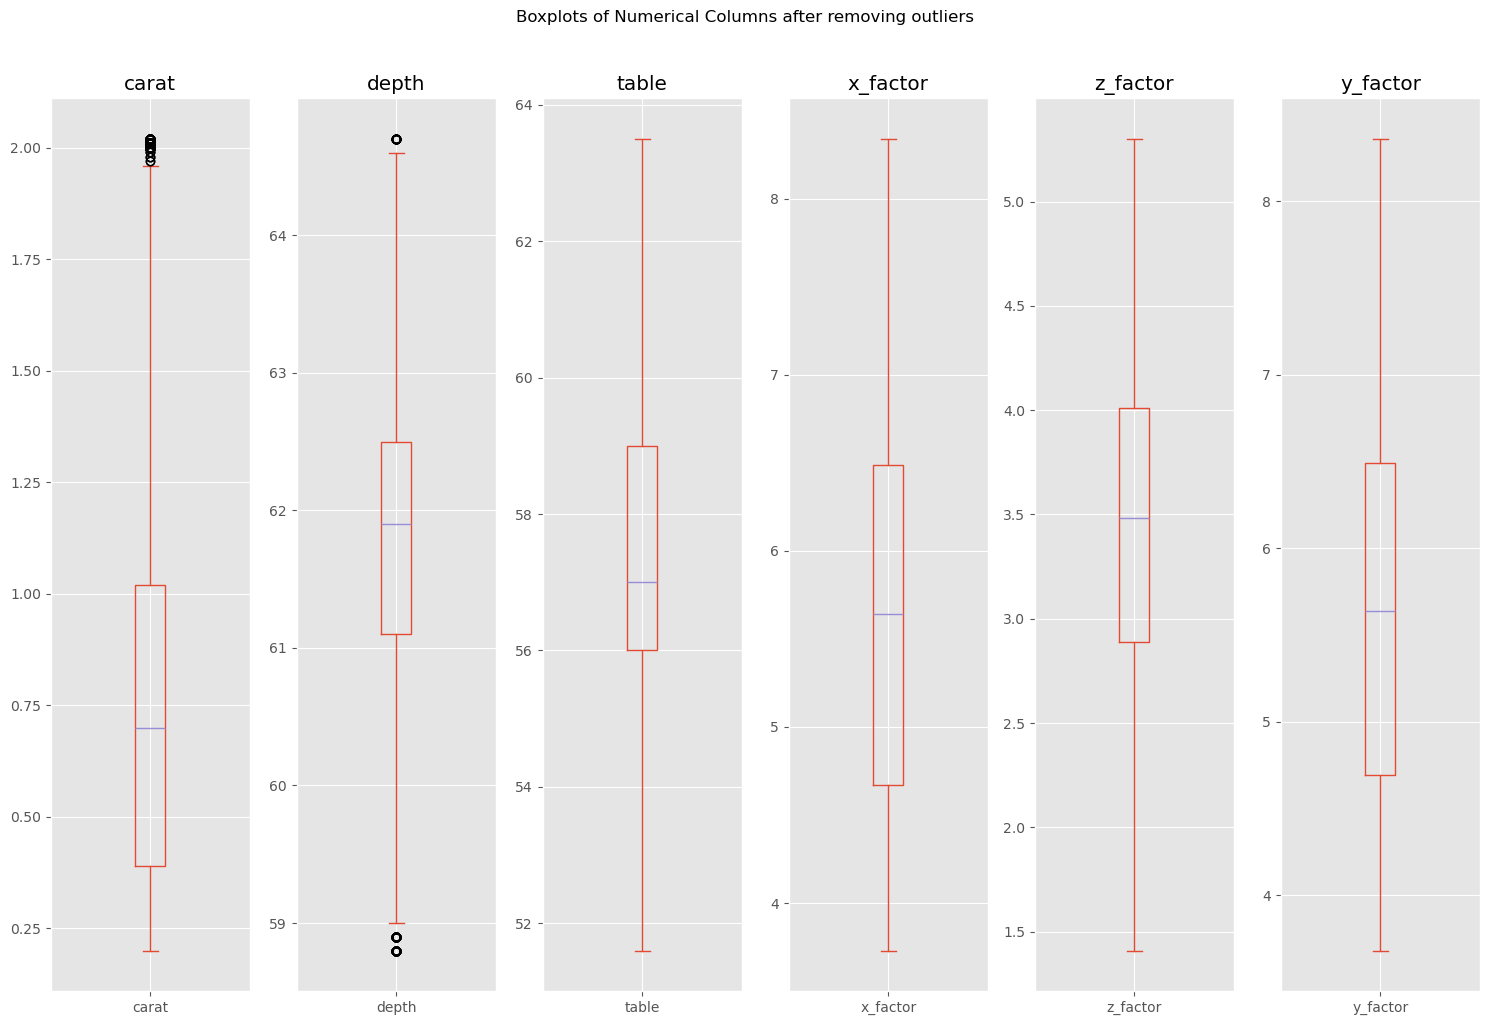

In [248]:
# plotting the boxplot for the numerical columns
fig, axes = plt.subplots(1, len(numerical_columns_without_price), figsize=(15, 10))
plt.suptitle('Boxplots of Numerical Columns after removing outliers', x=0.5, y=1.02, ha='center', fontsize='large')

for i, column in enumerate(numerical_columns_without_price):
    df_train[column].plot(kind='box', ax=axes[i])
    axes[i].set_title(column)
plt.tight_layout()
plt.show()

## **Scale Numerical Columns**

After removing the outliers from the numerical columns, we will scale the numerical columns in the training, validation, and test datasets using the `StandardScaler` method from the `scikit-learn` library. This will standardize the numerical columns to have a mean of 0 and a standard deviation of 1, which will help improve the performance of machine learning models.


In [284]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(df_train[numerical_columns_without_price])

X_train_num = scaler.transform(df_train[numerical_columns_without_price])
X_val_num = scaler.transform(df_val[numerical_columns_without_price])
X_test_num = scaler.transform(df_test[numerical_columns_without_price])

In [285]:
X_train_num

array([[ 1.18268145,  0.93041701, -1.37317942,  1.12687812,  1.24965253,
         1.16797761],
       [ 1.05564065,  0.28081947, -1.12465779,  1.0678983 ,  1.12245886,
         1.11855237],
       [ 0.87778352,  0.18801983,  1.36055853,  0.93027873,  0.93166836,
         0.89119626],
       ...,
       [-0.90078776, -0.92557595, -0.62761452, -0.87843568, -0.97623665,
        -0.93753763],
       [-1.20568569,  0.93041701,  0.366472  , -1.57636352, -1.48501132,
        -1.53064051],
       [ 0.16635501, -1.57517349,  0.366472  ,  0.45844019,  0.27980082,
         0.43648405]])

In [287]:
X_val_num 

array([[-0.69752247, -0.83277631,  0.366472  , -0.62285647, -0.70595011,
        -0.66075628],
       [-0.95160408,  0.74481771, -0.62761452, -1.0652051 , -0.99213586,
        -1.03638811],
       [ 0.42043662,  2.60081068,  0.366472  ,  0.50759003,  0.74087786,
         0.4463691 ],
       ...,
       [-0.79915511, -0.09037912,  0.366472  , -0.78996595, -0.81724457,
        -0.83868715],
       [ 1.03023249,  0.09522018, -0.13057126,  1.04823836,  1.05886203,
         1.07901218],
       [-0.92619592, -2.41037032,  1.85760179, -0.95707544, -1.11932953,
        -0.90788248]])

In [288]:
X_test_num

array([[ 2.24982422,  0.55921842, -0.13057126,  1.8444659 ,  1.93331849,
         1.89947117],
       [ 0.69992639, -0.09037912,  0.366472  ,  0.841809  ,  0.80447469,
         0.79234578],
       [-0.49425718, -0.73997666, -1.62170105, -0.31812741, -0.37206673,
        -0.30489455],
       ...,
       [-0.82456328,  0.37361912, -0.13057126, -0.87843568, -0.83314377,
        -0.85845724],
       [-0.67211431, -0.73997666,  0.86351527, -0.56387665, -0.64235327,
        -0.60144599],
       [ 1.15727329, -0.92557595, -0.13057126,  1.22517781,  1.10655965,
         1.2075178 ]])

## **Encode Categorical Variables**

Knowledge from the categorical inisght shows that the data is not balanced. This may affect the performance of the model. Therefore, we may need to consider encoding these categorical columns appropriately before training the model. We will use the `OneHotEncoder` method from the `scikit-learn` library to encode the categorical columns in the dataset.

In [294]:
# check the categorical columns
categorical_columns

['cut', 'color', 'clarity']

In [295]:
from sklearn.preprocessing import OneHotEncoder

# Fit encoder on df_train
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoder.fit(df_train[categorical_columns])


# Transform datasets
X_train_cat = encoder.transform(df_train[categorical_columns])
X_val_cat = encoder.transform(df_val[categorical_columns])
X_test_cat = encoder.transform(df_test[categorical_columns])

In [296]:
X_train_cat 

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [297]:
X_val_cat

array([[0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 1., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.]])

In [298]:
X_test_cat

array([[0., 0., 1., ..., 1., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 1.],
       ...,
       [0., 0., 1., ..., 1., 0., 0.],
       [0., 0., 0., ..., 1., 0., 0.],
       [0., 0., 1., ..., 0., 0., 1.]])

### **Transform Target Variable (Right Skewed)**

The target varibale is right skewed, and this may affect the performance of the model. Therefore, we will transform the target variable using the `np.log1p` method to achieve a more normal distribution and improve model performance. This will help to reduce the impact of outliers and make the model more robust to variations in the data.

In [299]:
import numpy as np

y_train_log = np.log1p(y_train)
y_val_log = np.log1p(y_val)
y_test_log = np.log1p(y_test)

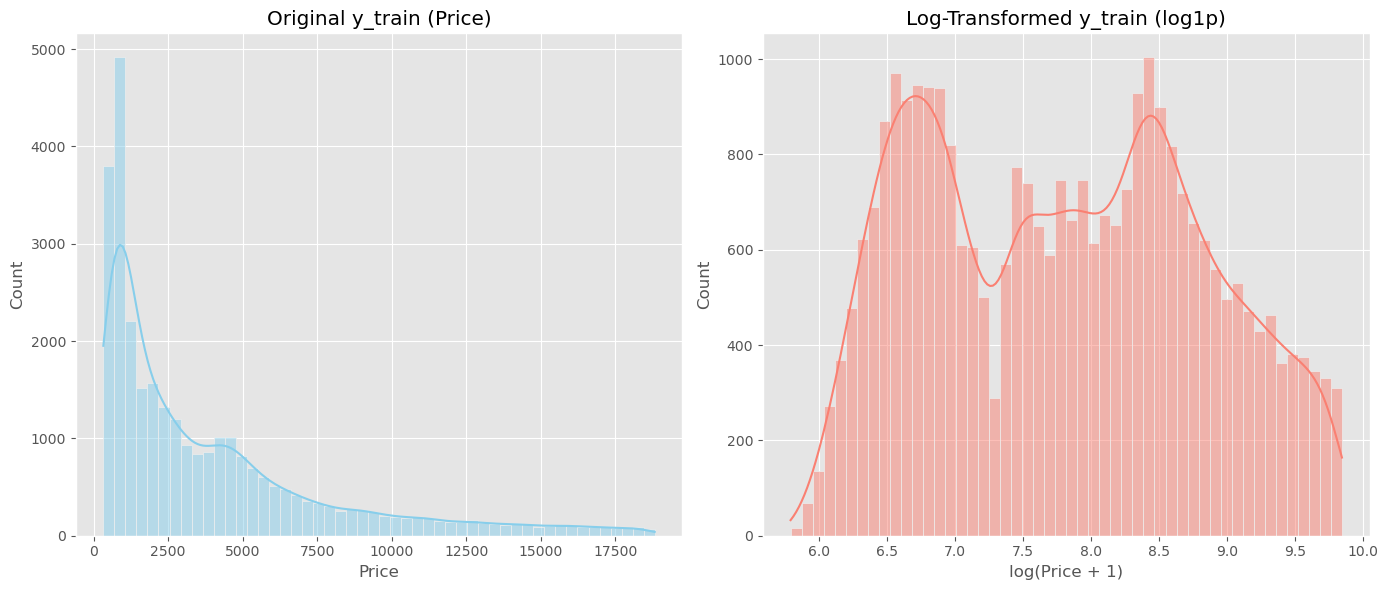

In [301]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 6))

# Before log transformation
plt.subplot(1, 2, 1)
sns.histplot(y_train, bins=50, kde=True, color='skyblue')
plt.title('Original y_train (Price)')
plt.xlabel('Price')

# After log transformation
plt.subplot(1, 2, 2)
sns.histplot(np.log1p(y_train), bins=50, kde=True, color='salmon')
plt.title('Log-Transformed y_train (log1p)')
plt.xlabel('log(Price + 1)')

plt.tight_layout()
plt.show()

In [300]:
y_train_log

array([8.80282316, 9.07612303, 8.80836915, ..., 7.84306402, 8.49964003,
       9.56001084])

it is important to 	During prediction phase, reverse the log transformation using:   
`np.expm1(predictions)` to get the actual price values.

### **Prepare the Data for Machine Learning Algorithms**

Following the feature engineering steps, we will prepare the data for machine learning algorithmsby combining the numerical and categorical columns in the training, validation, and test datasets. This will help to ensure that the data is ready for model training and evaluation.

In [302]:
import numpy as np

# Combine numeric + categorical
X_train_final = np.hstack([X_train_num, X_train_cat])
X_val_final = np.hstack([X_val_num, X_val_cat])
X_test_final = np.hstack([X_test_num, X_test_cat])

In [303]:
X_train_final

array([[ 1.18268145,  0.93041701, -1.37317942, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.05564065,  0.28081947, -1.12465779, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.87778352,  0.18801983,  1.36055853, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.90078776, -0.92557595, -0.62761452, ...,  0.        ,
         0.        ,  0.        ],
       [-1.20568569,  0.93041701,  0.366472  , ...,  1.        ,
         0.        ,  0.        ],
       [ 0.16635501, -1.57517349,  0.366472  , ...,  0.        ,
         0.        ,  0.        ]])

In [304]:
X_val_final 

array([[-0.69752247, -0.83277631,  0.366472  , ...,  1.        ,
         0.        ,  0.        ],
       [-0.95160408,  0.74481771, -0.62761452, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.42043662,  2.60081068,  0.366472  , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [-0.79915511, -0.09037912,  0.366472  , ...,  0.        ,
         0.        ,  0.        ],
       [ 1.03023249,  0.09522018, -0.13057126, ...,  1.        ,
         0.        ,  0.        ],
       [-0.92619592, -2.41037032,  1.85760179, ...,  1.        ,
         0.        ,  0.        ]])

In [305]:
X_test_final

array([[ 2.24982422,  0.55921842, -0.13057126, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.69992639, -0.09037912,  0.366472  , ...,  0.        ,
         0.        ,  0.        ],
       [-0.49425718, -0.73997666, -1.62170105, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [-0.82456328,  0.37361912, -0.13057126, ...,  1.        ,
         0.        ,  0.        ],
       [-0.67211431, -0.73997666,  0.86351527, ...,  1.        ,
         0.        ,  0.        ],
       [ 1.15727329, -0.92557595, -0.13057126, ...,  0.        ,
         0.        ,  1.        ]])

# 📚 6. BUILDING AND TRAINING THE MODEL
___

<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">
This section deals with ...

</div>

# 📚 7. EVALUATING THE MODEL
___

<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">
This section deals with ...

</div>

# 📚 8. MODEL DEPLOYMENT
___

<div style="font-family: Avenir, sans-serif; font-size: 16px; line-height: 1.6; color: white; background-color: #333; padding: 10px; border-radius: 5px;">
This section deals with ...

</div>